# Heart Disease Dataset  
(Dataset disponível em > [Kaggle](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset?resource=download) <)

A principal ideia desse Dataset é de alguma maneira conseguir prever se um indíviduo terá alguma doença cardíaca a partir de fatores pessoiais. 


Esse Dataset reúne dados (sintéticos para efeitos de estudos)  de 1988 de 4 lugares diferentes, sendo eles: Cleveland, Hungary, Switzerland e Long Beach V. As colunas são compostas por essas 14 variáveis.



1. **age**  
   Idade do paciente em anos.

2. **sex**  
   Sexo do paciente:  
   - 1 = Masculino  
   - 0 = Feminino

3. **chest pain type (4 values)**  
   Tipo de dor no peito apresentada pelo paciente:  
   - 0 = Angina típica  
   - 1 = Angina atípica  
   - 2 = Dor não anginosa  
   - 3 = Assintomático

4. **resting blood pressure**  
   Pressão arterial em repouso (em mm Hg) medida na admissão do hospital.

5. **serum cholestoral in mg/dl**  
   Nível de colesterol sérico (em mg/dl).

6. **fasting blood sugar > 120 mg/dl**  
   Açúcar no sangue em jejum maior que 120 mg/dl:  
   - 1 = Verdadeiro  
   - 0 = Falso

7. **resting electrocardiographic results (values 0, 1, 2)**  
   Resultados do exame eletrocardiográfico em repouso:  
   - 0 = Normal  
   - 1 = Anormalidade na onda ST-T  
   - 2 = Hipertrofia ventricular esquerda provável ou definitiva

8. **maximum heart rate achieved**  
   Frequência cardíaca máxima atingida durante o exercício.

9. **exercise induced angina**  
   Angina induzida por exercício:  
   - 1 = Sim  
   - 0 = Não

10. **oldpeak**  
    Depressão do segmento ST induzida pelo exercício em relação ao repouso (medida em mm).  
    Indica alterações no ECG associadas à isquemia.

11. **the slope of the peak exercise ST segment**  
    Inclinação do segmento ST durante o exercício máximo:  
    - 0 = Ascendente  
    - 1 = Plano  
    - 2 = Descendente

12. **number of major vessels (0–3) colored by flourosopy**  
    Número de vasos principais (de 0 a 3) coloridos pela fluoroscopia.

13. **thal**  
    Resultado do exame de talassemia:  
    - 0 = Normal  
    - 1 = Defeito fixo  
    - 2 = Defeito reversível

14. **target**
   Possui ou não possui doença cardíaca
   - 0 = Indivíduo não possúi doença cardíaca
   - 1 = Indivíduo possúi doença cardíaca

## Análise exploratória :

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

In [ ]:
heart_ds = pd.read_csv("../data/heart.csv")
heart_ds.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
len(heart_ds)

1025

Temos inicialmente 1025 pacientes para analisar. Porém, ao analisarmos mais a fundo, vemos que vários desses dados são dados duplicados, ou seja, são apenas linhas repetidas. Elaborar modelos com Datasets com dados repetidos **não é um procedimento padrão**, já que dessa maneira estamos enviesando a distribuição dos dados e requerendo mais processamento sem acrescentar nada ao modelo. Então, devemos eliminar as linhas duplicadas para trabalharmos com um Dataset adequado.

In [4]:
heart_ds.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1020     True
1021     True
1022     True
1023     True
1024     True
Length: 1025, dtype: bool

In [5]:
heart_ds = heart_ds.drop_duplicates()
len(heart_ds)

302

O tamanho do nosso Dataset decresceu muito, porém agora temos mais fidelidade nos dados coletados.

In [6]:

heart_ds = heart_ds.reset_index(drop=True) # Tirando também dados incompletos caso existam
heart_ds



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
298,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
299,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
300,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


Aqui veremos as distribuicões das variáveis, onde podemos fazer a identificação de `outliers` e também ter uma visão do equilíbrio das distribuiçoes dos dados.

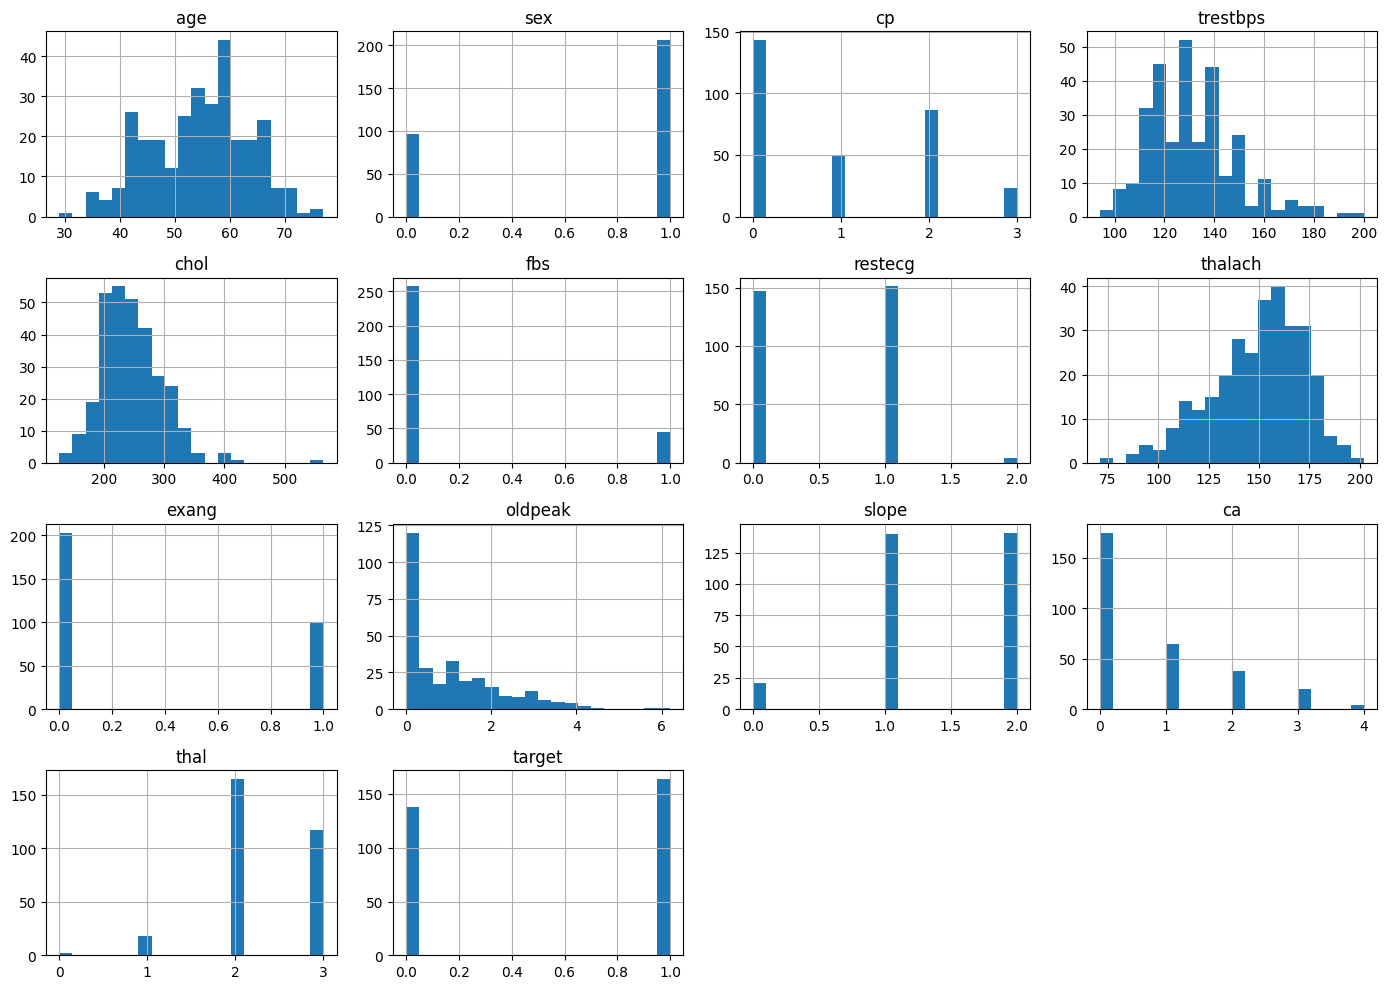

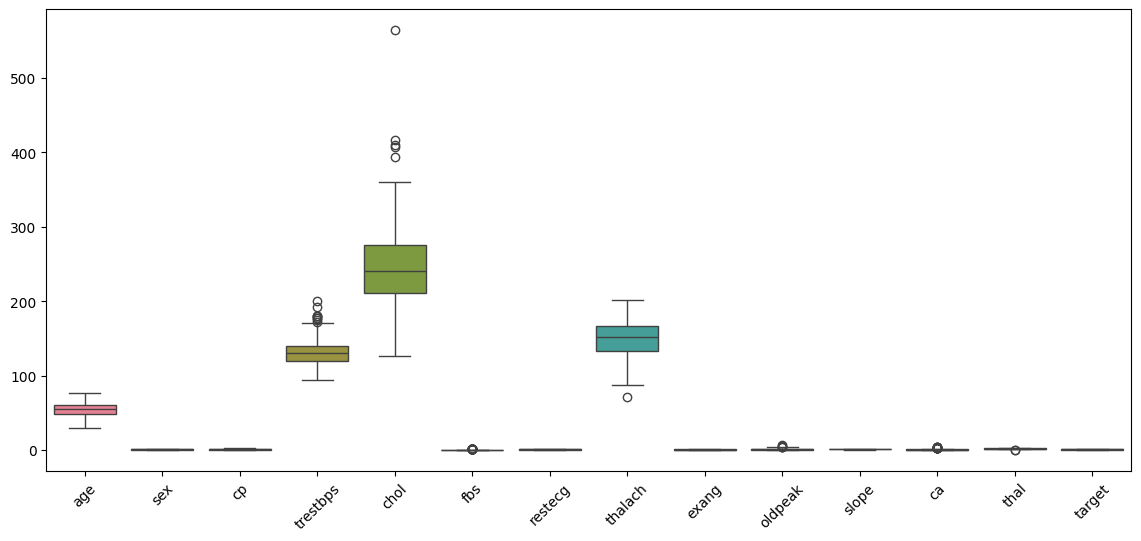

In [7]:
df = heart_ds

df.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

# Boxplots para verificar outliers
plt.figure(figsize=(14, 6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.show()


Temos um grande outlier nos dados de `colesterol`, porém pode ser explicado por alguma doença presente no indivíduo que traz essa característica. Outra importante análise é a do balancemanto entre indíviduos classificados com `target = 0  e target = 1`.

É muito importante treinar modelos preditivos com um Dataset bem balanceado, uma vez que, caso contrário, seria benéfico ao modelo "chutar" mais de algum tipo dependendo do balanceamento. Por exemplo, se um dataset tiver 90% dos dados classificados como `não possui doença cardíaca` e o modelo classificar apenas como `não possui doença cardíaca` a acurácia do modelo será de 90%, dando a falsa impressão de que o modelo é bom. Porém o modelo estará cometendo um dos mais graves erros na área médica: _classificar um paciente doente como um paciente normal_. Logo, é de suma importancia olhar para as distribuições das classes para podermos tomar decisões de forma a atenuar esse problema. 

Podemos ver que o Dataset usado apresenta desequilíbrio de algumas variáveis que pretendemos utilizar como variáveis preditoras, mas o nível de desequilíbrio dessas variáveis é pequeno e não deve causar impacto significativo na qualidade do nosso modelo.

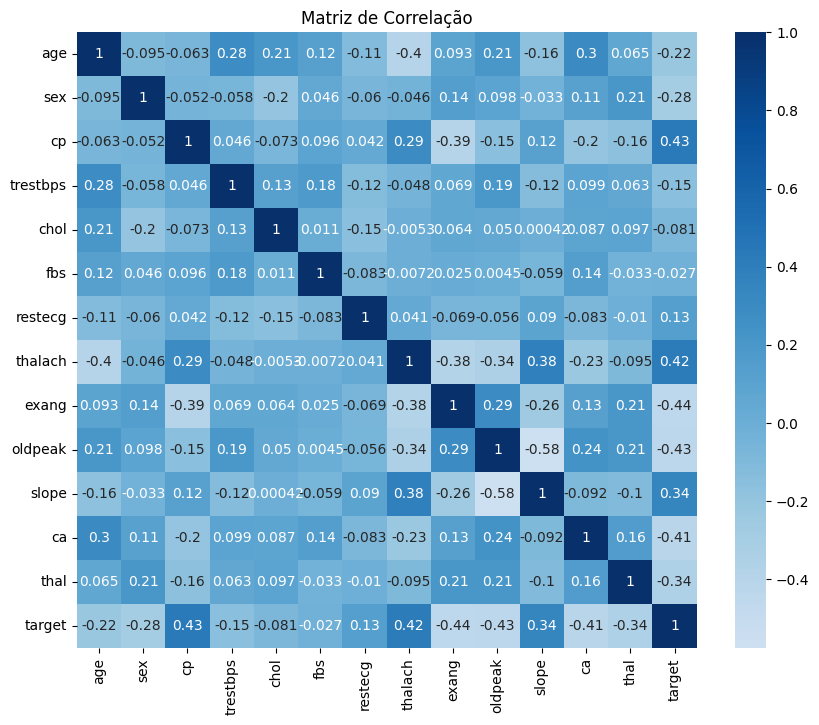

In [8]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="Blues", center=0)
plt.title("Matriz de Correlação")
plt.show()

Usar duas variáveis com alta correlação como preditoras pode causar instabilidade numérica na matriz de covariância e ocasionar malefícios para os testes de hipóteses em regressão linear ou em modelos que exigem independência linear dos preditores. Logo, se duas variáveis tem correlação acima de `0.4 em módulo`, vamos escolher apenas uma delas para serem preditora do modelo.

Uma lista dos pares de variáveis com correlação são:


1. `age x thalach` : -0.4
2. `slope x thalach`: 0.38
3. `thalach x oldpeak`: 0.34
4. `exang x oldpeak`: 0.29
5. `cp x exang`: -0.39
6. `thalach x cp`: 0.29

### Geração de dados:

Como os dados são sintéticos e foram melhorados para facilitar a análise e criação de modelos, vamos apagar dados artificialmente da base e tentar preenchê-los de modo a simular um ambiente real de trabalho com dados. Os dados gerados aqui serão usados para treinar o modelo final de regressao 

Vamos passar por cada dado do dataset e "apagá-lo" `preencher com np.nan` com probabilidade 20%. Apos isso, vamos tentar preencer os valores faltantes em cada coluna. Para tal realização, testaremos diferentes modelos de preenchimento, desde técnicas simples como preenchimento pelo último valor até métodos avançados uso de métodos prontos de `imputer do sklearn` e modelos feitos aqui. Para dar um exemplo da performance de diferentes modelos, testaremos varios modelos para completar a base e exibiremos suas metricas aqui. O modelo que realmente usaremos para preencher a base sera um modelo de `regressão linear` para variaveis numericas e modelo de `regressao logistica` para variaveis categoricas.

Modelos a serem testados:
- Preenchimentos simples;
- Funções prontas de imputer do sklearn;
- LDA e QDA para variáveis categóricas;
- Regressão linear para variáveis contínuas;
- Regressõo logística para variáveis categóricas;
- Boosting;
- Redes neurais - pequenos MLP;

In [9]:
# Criar uma cópia do dataset com valores faltantes (20% de probabilidade por célula)
import numpy as np
import pandas as pd

base = heart_ds.copy()
fonte = "heart_ds (kernel)"

print(f"Fonte de dados: {fonte} - shape: {base.shape}")

# 2) Definir coluna alvo (não apagaremos o alvo para manter a tarefa de classificação)
if 'target' in base.columns:
    target_col = 'target'

# 3) Copiar e aplicar máscara aleatória de 20% (por célula), exceto na coluna alvo
rng = np.random.default_rng(42)
mask = rng.random(base.shape) < 0.20
if target_col in base.columns:
    target_idx = base.columns.get_loc(target_col)
    mask[:, target_idx] = False

heart_ds_missing = base.copy()
# Aplicar NaN com base na máscara (funciona para numéricos e também converte ints para float quando necessário)
heart_ds_missing = heart_ds_missing.mask(mask)

# 4) Relatório de faltantes por coluna
na_counts = heart_ds_missing.isna().sum()
print("Valores faltantes por coluna (após mascarar 20%):")
print(na_counts.to_string())

# 5) Pré-visualização
display(heart_ds_missing.head())

Fonte de dados: heart_ds (kernel) - shape: (302, 14)
Valores faltantes por coluna (após mascarar 20%):
age         54
sex         65
cp          70
trestbps    62
chol        61
fbs         63
restecg     74
thalach     68
exang       58
oldpeak     56
slope       58
ca          58
thal        59
target       0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,0.0,125.0,NaN,0.0,1.0,168.0,NaN,1.0,2.0,2.0,3.0,0
1,53.0,1.0,0.0,NaN,203.0,1.0,0.0,155.0,1.0,3.1,0.0,NaN,3.0,0
2,NaN,1.0,0.0,145.0,174.0,0.0,1.0,NaN,NaN,2.6,0.0,0.0,3.0,0
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,NaN,NaN,NaN,2.0,1.0,3.0,0
4,62.0,0.0,NaN,NaN,294.0,1.0,1.0,106.0,0.0,1.9,1.0,3.0,NaN,0


In [10]:
# ===================================================
#               TESTE DE INPUTÇÃO
#         PODEMOS VER A PERFORMANCE DE VÁRIOS MODELOS
# ===================================================

# Imputação por coluna com múltiplos modelos (simple, sklearn imputers, LDA/QDA, LR/Reg, Boosting, MLP)
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, f1_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier

full = heart_ds_missing.copy()
label_col = 'target' if 'target' else None
feature_cols = [c for c in full.columns if c != label_col]

# Inferir tipos para features
known_cats = ['cp','thal','slope','restecg']
cat_cols = []
for c in feature_cols:
    if (full[c].dtype=='object' or str(full[c].dtype)=='category') or c in known_cats:
        cat_cols.append(c)
num_cols = [c for c in feature_cols if c not in cat_cols]

# Aux: pré-processador para X (exceto coluna alvo de imputação)
def make_X_preprocessor(X_cols):
    num_in = [c for c in X_cols if c in num_cols]
    cat_in = [c for c in X_cols if c in cat_cols]
    return ColumnTransformer([
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_in),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))
        ]), cat_in)
    ], remainder='drop')

# CV config (usamos 3-fold para tempo razoável)
skf_cls = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
kf_reg = KFold(n_splits=3, shuffle=True, random_state=42)

# Contêineres de resultados por coluna
col_results = {}

for col in feature_cols:
    is_categorical = col in cat_cols
    # Dados para avaliação (usar apenas linhas com valor observado na coluna)
    obs_mask = full[col].notna()
    if obs_mask.sum() < 10:
        # Muito poucos exemplos observados, pular
        continue

    X_all = full.loc[obs_mask, [c for c in feature_cols if c != col and c != label_col]].copy()
    y_col = full.loc[obs_mask, col].copy()

    # Garantir tipos para y de classificação
    if is_categorical:
        y_col = y_col.astype('category')

    # Modelos por tipo
    results_models = {}

    if is_categorical:
        # Baseline - moda simples
        try:
            accs, f1s = [], []
            splitter = skf_cls.split(X_all, y_col)
            for tr_idx, te_idx in splitter:
                y_tr, y_te = y_col.iloc[tr_idx], y_col.iloc[te_idx]
                mode_val = y_tr.mode().iloc[0]
                y_pred = np.array([mode_val] * len(te_idx))
                accs.append(accuracy_score(y_te, y_pred))
                f1s.append(f1_score(y_te, y_pred, average='weighted', zero_division=0))
            results_models['simple_mode'] = {
                'acc_mean': float(np.mean(accs)), 'acc_std': float(np.std(accs)),
                'f1_mean': float(np.mean(f1s)), 'f1_std': float(np.std(f1s))
            }
        except Exception:
            pass

        # Pipelines de classificação
        clf_models = {
            'logistic': LogisticRegression(max_iter=5000, multi_class='auto', solver='lbfgs'),
            'lda': LDA(),
            'qda': QDA(),
            'gb_clf': GradientBoostingClassifier(random_state=42),
            'mlp_clf': MLPClassifier(hidden_layer_sizes=(32,), activation='relu', max_iter=1000, random_state=42)
        }

        for name, est in clf_models.items():
            accs, f1s = [], []
            splitter = skf_cls.split(X_all, y_col)
            for tr_idx, te_idx in splitter:
                X_tr, X_te = X_all.iloc[tr_idx], X_all.iloc[te_idx]
                y_tr, y_te = y_col.iloc[tr_idx], y_col.iloc[te_idx]
                pre = make_X_preprocessor(X_all.columns)
                pipe = Pipeline([
                    ('pre', pre),
                    ('clf', est)
                ])
                try:
                    pipe.fit(X_tr, y_tr)
                    y_pred = pipe.predict(X_te)
                    accs.append(accuracy_score(y_te, y_pred))
                    f1s.append(f1_score(y_te, y_pred, average='weighted', zero_division=0))
                except Exception:
                    # Caso falhe em algum fold (p.ex., QDA singular), pula o fold
                    continue
            if len(accs) > 0:
                results_models[name] = {
                    'acc_mean': float(np.mean(accs)), 'acc_std': float(np.std(accs)),
                    'f1_mean': float(np.mean(f1s)), 'f1_std': float(np.std(f1s))
                }

    else:
        # Numérico - baselines simples
        try:
            maes, rmses = [], []
            for tr_idx, te_idx in kf_reg.split(X_all):
                y_tr, y_te = y_col.iloc[tr_idx], y_col.iloc[te_idx]
                mean_val = y_tr.mean()
                y_pred = np.array([mean_val] * len(te_idx))
                maes.append(mean_absolute_error(y_te, y_pred))
                rmses.append(np.sqrt(mean_squared_error(y_te, y_pred)))
            results_models['simple_mean'] = {
                'mae_mean': float(np.mean(maes)), 'mae_std': float(np.std(maes)),
                'rmse_mean': float(np.mean(rmses)), 'rmse_std': float(np.std(rmses))
            }
        except Exception:
            pass

        try:
            maes, rmses = [], []
            for tr_idx, te_idx in kf_reg.split(X_all):
                y_tr, y_te = y_col.iloc[tr_idx], y_col.iloc[te_idx]
                median_val = y_tr.median()
                y_pred = np.array([median_val] * len(te_idx))
                maes.append(mean_absolute_error(y_te, y_pred))
                rmses.append(np.sqrt(mean_squared_error(y_te, y_pred)))
            results_models['simple_median'] = {
                'mae_mean': float(np.mean(maes)), 'mae_std': float(np.std(maes)),
                'rmse_mean': float(np.mean(rmses)), 'rmse_std': float(np.std(rmses))
            }
        except Exception:
            pass

        # Regressão, Boosting e MLP
        reg_models = {
            'linreg': LinearRegression(),
            'gb_reg': GradientBoostingRegressor(random_state=42),
            'mlp_reg': MLPRegressor(hidden_layer_sizes=(32,), activation='relu', max_iter=1000, random_state=42)
        }
        for name, est in reg_models.items():
            maes, rmses = [], []
            for tr_idx, te_idx in kf_reg.split(X_all):
                X_tr, X_te = X_all.iloc[tr_idx], X_all.iloc[te_idx]
                y_tr, y_te = y_col.iloc[tr_idx], y_col.iloc[te_idx]
                pre = make_X_preprocessor(X_all.columns)
                pipe = Pipeline([
                    ('pre', pre),
                    ('reg', est)
                ])
                try:
                    pipe.fit(X_tr, y_tr)
                    y_pred = pipe.predict(X_te)
                    maes.append(mean_absolute_error(y_te, y_pred))
                    rmses.append(np.sqrt(mean_squared_error(y_te, y_pred)))
                except Exception:
                    continue
            if len(maes) > 0:
                results_models[name] = {
                    'mae_mean': float(np.mean(maes)), 'mae_std': float(np.std(maes)),
                    'rmse_mean': float(np.mean(rmses)), 'rmse_std': float(np.std(rmses))
                }

        # Imputers globais p/ numéricos (KNN, Iterative) — avaliados projetando a coluna
        # Observação: avaliamos imputando somente numéricos e categóricas por modo
        for imp_name, imp in [('knn_num', KNNImputer(n_neighbors=5)), ('iter_num', IterativeImputer(random_state=42, max_iter=10))]:
            try:
                maes, rmses = [], []
                for tr_idx, te_idx in kf_reg.split(X_all):
                    # Fit imputers no treino usando TODAS as features (exceto 'col' removida do X_all e sem 'target')
                    train_df = full.loc[obs_mask].iloc[tr_idx][feature_cols].copy()
                    test_df = full.loc[obs_mask].iloc[te_idx][feature_cols].copy()

                    # Não usar label_col como preditor (já removido)
                    # Imputar categóricas por modo
                    for c in cat_cols:
                        mode_val = train_df[c].mode(dropna=True)
                        if len(mode_val) > 0:
                            mv = mode_val.iloc[0]
                            train_df[c] = train_df[c].fillna(mv)
                            test_df[c] = test_df[c].fillna(mv)
                        else:
                            train_df[c] = train_df[c].fillna('NA')
                            test_df[c] = test_df[c].fillna('NA')

                    # Imputar numéricos via KNN/Iterative
                    num_train = train_df[num_cols].copy()
                    num_test = test_df[num_cols].copy()
                    num_imputed_train = pd.DataFrame(imp.fit_transform(num_train), columns=num_cols)
                    num_imputed_test = pd.DataFrame(imp.transform(num_test), columns=num_cols)

                    # Previsão da coluna-alvo numérica no teste
                    y_pred = num_imputed_test[col].values
                    y_true = y_col.iloc[te_idx].values
                    # Filtrar apenas índices correspondentes (já alinhados)
                    maes.append(mean_absolute_error(y_true, y_pred))
                    rmses.append(np.sqrt(mean_squared_error(y_true, y_pred)))
                if len(maes) > 0:
                    results_models[f'{imp_name}_imputer'] = {
                        'mae_mean': float(np.mean(maes)), 'mae_std': float(np.std(maes)),
                        'rmse_mean': float(np.mean(rmses)), 'rmse_std': float(np.std(rmses))
                    }
            except Exception:
                pass

    col_results[col] = results_models

# Exibir resumo por coluna
from IPython.display import display

summary_tables = {}
for col, res in col_results.items():
    df = pd.DataFrame(res).T
    summary_tables[col] = df
    print(f"\nResumo da coluna: {col}")
    display(df)

# Imputar valores faltantes no dataset com o melhor modelo por coluna
heart_ds_modelwise = full.copy()

for col, res in col_results.items():
    if heart_ds_modelwise[col].isna().sum() == 0:
        continue
    is_categorical = col in cat_cols
    obs_mask = heart_ds_modelwise[col].notna()
    miss_mask = ~obs_mask
    X_all = heart_ds_modelwise.loc[obs_mask, [c for c in feature_cols if c != col and c != label_col]].copy()
    y_col = heart_ds_modelwise.loc[obs_mask, col].copy()
    # Escolher melhor
    if is_categorical:
        # Maximizar f1_mean
        best_name = max(res.keys(), key=lambda k: res[k].get('f1_mean', -1))
        if best_name == 'simple_mode':
            # Preencher com a moda preservando o dtype original da coluna
            mode_val = y_col.mode(dropna=True).iloc[0]
            target_dtype = heart_ds_modelwise[col].dtype
            if pd.api.types.is_numeric_dtype(target_dtype):
                try:
                    fill_val = pd.to_numeric(pd.Series([mode_val])).iloc[0]
                except Exception:
                    fill_val = mode_val
            else:
                fill_val = str(mode_val)
            heart_ds_modelwise.loc[miss_mask, col] = fill_val
        else:
            est_map = {
                'logistic': LogisticRegression(max_iter=5000, multi_class='auto', solver='lbfgs'),
                'lda': LDA(),
                'qda': QDA(),
                'gb_clf': GradientBoostingClassifier(random_state=42),
                'mlp_clf': MLPClassifier(hidden_layer_sizes=(32,), activation='relu', max_iter=1000, random_state=42)
            }
            est = est_map.get(best_name)
            if est is not None:
                pre = make_X_preprocessor(X_all.columns)
                pipe = Pipeline([('pre', pre), ('clf', est)])
                # Treinar com categorias nativas para manter classes como números quando aplicável
                pipe.fit(X_all, y_col.astype('category'))
                X_miss = heart_ds_modelwise.loc[miss_mask, X_all.columns]
                preds = pipe.predict(X_miss)
                # Garantir que os valores previstos respeitam o dtype original da coluna
                target_dtype = heart_ds_modelwise[col].dtype
                preds_series = pd.Series(preds)
                if pd.api.types.is_numeric_dtype(target_dtype):
                    preds_series = pd.to_numeric(preds_series, errors='coerce')
                else:
                    preds_series = preds_series.astype(str)
                heart_ds_modelwise.loc[miss_mask, col] = preds_series.values
            else:
                # fallback para modo
                mode_val = y_col.mode(dropna=True).iloc[0]
                target_dtype = heart_ds_modelwise[col].dtype
                if pd.api.types.is_numeric_dtype(target_dtype):
                    try:
                        fill_val = pd.to_numeric(pd.Series([mode_val])).iloc[0]
                    except Exception:
                        fill_val = mode_val
                else:
                    fill_val = str(mode_val)
                heart_ds_modelwise.loc[miss_mask, col] = fill_val
    else:
        # Minimizar rmse_mean
        best_name = min(res.keys(), key=lambda k: res[k].get('rmse_mean', 1e9))
        if best_name == 'simple_mean':
            mean_val = y_col.mean()
            heart_ds_modelwise.loc[miss_mask, col] = mean_val
        elif best_name == 'simple_median':
            med_val = y_col.median()
            heart_ds_modelwise.loc[miss_mask, col] = med_val
        elif best_name in ('knn_imputer', 'knn_num_imputer', 'knn_num_imputer', 'knn_num_imputer'):  # tolerant
            imp = KNNImputer(n_neighbors=5)
            # Imputar numéricos com KNN no dataset inteiro (features) e preencher a coluna
            df_features = heart_ds_modelwise[feature_cols].copy()
            # Categóricas por modo
            for c in cat_cols:
                mv = df_features[c].mode(dropna=True)
                mv = mv.iloc[0] if len(mv)>0 else 'NA'
                df_features[c] = df_features[c].fillna(mv)
            num_imputed = pd.DataFrame(imp.fit_transform(df_features[num_cols]), columns=num_cols)
            heart_ds_modelwise[col] = num_imputed[col].values
        elif best_name.startswith('iter'):  # iterative_imputer
            imp = IterativeImputer(random_state=42, max_iter=10)
            df_features = heart_ds_modelwise[feature_cols].copy()
            for c in cat_cols:
                mv = df_features[c].mode(dropna=True)
                mv = mv.iloc[0] if len(mv)>0 else 'NA'
                df_features[c] = df_features[c].fillna(mv)
            num_imputed = pd.DataFrame(imp.fit_transform(df_features[num_cols]), columns=num_cols)
            heart_ds_modelwise[col] = num_imputed[col].values
        else:
            # Mapear regressão/GB/MLP
            est_map = {
                'linreg': LinearRegression(),
                'gb_reg': GradientBoostingRegressor(random_state=42),
                'mlp_reg': MLPRegressor(hidden_layer_sizes=(32,), activation='relu', max_iter=1000, random_state=42)
            }
            est = est_map.get(best_name)
            if est is not None:
                pre = make_X_preprocessor(X_all.columns)
                pipe = Pipeline([('pre', pre), ('reg', est)])
                pipe.fit(X_all, y_col)
                X_miss = heart_ds_modelwise.loc[miss_mask, X_all.columns]
                preds = pipe.predict(X_miss)
                heart_ds_modelwise.loc[miss_mask, col] = preds
            else:
                # fallback média
                heart_ds_modelwise.loc[miss_mask, col] = y_col.mean()

print("Imputação por coluna concluída. Faltantes por coluna agora:")
print(heart_ds_modelwise.isna().sum().to_string())

display(heart_ds_modelwise.head())

/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] d


Resumo da coluna: age


/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,mae_mean,mae_std,rmse_mean,rmse_std
simple_mean,7.375793,0.233970,8.958043,0.276565
simple_median,7.428397,0.242899,9.086569,0.337214
linreg,6.911304,0.790947,8.318682,0.966908
gb_reg,7.324532,0.640922,9.029889,0.794477
mlp_reg,9.713941,0.129426,12.015339,0.400084
knn_num_imputer,0.000000,0.000000,0.000000,0.000000
iter_num_imputer,0.000000,0.000000,0.000000,0.000000



Resumo da coluna: sex


...

,acc_mean,acc_std,f1_mean,f1_std
simple_mode,0.547325,0.005820,0.387222,0.006791
logistic,0.592593,0.046193,0.572706,0.060232
lda,0.596708,0.050736,0.583380,0.057568
qda,0.543210,0.000000,0.382420,0.000000
gb_clf,0.592593,0.043939,0.578459,0.050763
mlp_clf,0.596708,0.082099,0.587277,0.089110


/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Imputação por coluna concluída. Faltantes por coluna agora:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0


/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,0.0,125.0,209.2,0.0,1.0,168.0,0.0,1.0,2.0,2.0,3.0,0
1,53.0,1.0,0.0,124.8,203.0,1.0,0.0,155.0,1.0,3.1,0.0,0.4,3.0,0
2,52.6,1.0,0.0,145.0,174.0,0.0,1.0,142.8,0.2,2.6,0.0,0.0,3.0,0
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,149.2,0.2,1.7,2.0,1.0,3.0,0
4,62.0,0.0,0.0,130.8,294.0,1.0,1.0,106.0,0.0,1.9,1.0,3.0,2.0,0


## Resumo - Imputação por coluna apenas para comparaçao de modelos. 

- Estratégia: para cada variável testamos métodos apropriados (baselines: média/mediana/moda; imputers do scikit‑learn: KNN e Iterative; modelos supervisionados: Regressão Linear, Regressão Logística, LDA, QDA, Gradient Boosting e MLP). Cada método foi avaliado por validação cruzada (3‑fold) usando apenas as observações disponíveis da coluna.
- Consistência de tipos: as previsões categóricas são convertidas de volta ao dtype original da coluna antes de serem atribuídas ao DataFrame, evitando misturar strings e números o que quebraria encoders como OneHotEncoder.
- Resultado: a imputação por coluna foi concluída com sucesso; o DataFrame final (`heart_ds_modelwise`) não contém valores faltantes.
- Limitações e observações: QDA pode falhar em folds com matrizes de covariância singulares (tratado por exceções) e alguns MLPs mostraram avisos de convergência (poderíamos aumentar `max_iter` ou ajustar hiperparâmetros).

### Imputação de dados faltantes em `heart_ds`

In [11]:
# ===================================================
#     INPUTAÇÃO DEFINITIVA USANDO MODELOS LINEARES
#    COM BACKWARD SELECTION PARA VARIÁVEIS NUMERICAS
#       E SELEÇAO DE FEATURES PARA CATEGÓRICAS
# ===================================================


import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, f1_score
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

print("="*80)
print("IMPUTAÇÃO COM BACKWARD SELECTION")
print("="*80)
print()

skf_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf_reg = KFold(n_splits=5, shuffle=True, random_state=42)

# Dicionários para armazenar resultados
cv_results = {}
final_models = {}
selected_features_by_col = {}

for col in feature_cols:
    is_categorical = col in cat_cols
    obs_mask = full[col].notna()
    if obs_mask.sum() < 10:
        continue

    X_all = full.loc[obs_mask, [c for c in feature_cols if c != col and c != label_col]].copy()
    y_col = full.loc[obs_mask, col].copy()

    print(f"\nColuna: {col} ({'Categórica' if is_categorical else 'Numérica'})")
    print(f"  Features disponíveis: {X_all.shape[1]}")
    
    # Pré-processar X para ter valores numéricos
    pre = make_X_preprocessor(X_all.columns)
    X_all_processed = pre.fit_transform(X_all)
    
    print(f"  Features após preprocessamento: {X_all_processed.shape[1]}")
    
    # ========================================================================
    # BACKWARD SELECTION NO CONJUNTO COMPLETO
    # ========================================================================
    print(f"  Aplicando feature selection...")
    
    threshold_p = 0.05
    n_features = X_all_processed.shape[1]
    features = list(range(n_features))
    
    if is_categorical:
        # Backward selection para classificação usando LogisticRegression do sklearn
        y_col_cat = y_col.astype('category')
        y_codes = y_col_cat.cat.codes
        
        # Usar cross-validation score como critério para remover features
        best_score = 0
        removed_any = True
        
        while len(features) > 1 and removed_any:
            removed_any = False
            worst_feature_idx = None
            worst_feature_score = best_score
            
            # Testar remover cada feature
            for i in range(len(features)):
                test_features = features[:i] + features[i+1:]
                X_subset = X_all_processed[:, test_features]
                
                clf = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
                scores = cross_val_score(clf, X_subset, y_codes, cv=3, scoring='accuracy')
                mean_score = scores.mean()
                
                # Se remover essa feature não piora (ou melhora) o score, marcá-la para remoção
                if mean_score >= worst_feature_score:
                    worst_feature_score = mean_score
                    worst_feature_idx = i
                    removed_any = True
            
            # Se encontrou uma feature para remover
            if removed_any and worst_feature_idx is not None:
                removed_feature = features[worst_feature_idx]
                print(f"    Removendo feature índice {removed_feature} (score sem ela = {worst_feature_score:.4f})")
                features.pop(worst_feature_idx)
                best_score = worst_feature_score
    else:
        # Backward selection para regressão usando OLS
        while len(features) > 0:
            X_subset = X_all_processed[:, features]
            X_with_const = sm.add_constant(X_subset)
            
            model = sm.OLS(y_col, X_with_const)
            results = model.fit()
            
            # Obter p-valores (excluir constante)
            pvalues = results.pvalues[1:]
            max_pval = pvalues.max()
            
            if max_pval > threshold_p:
                # Remover feature com maior p-valor
                worst_idx = pvalues.argmax()
                removed_feature = features[worst_idx]
                print(f"    Removendo feature índice {removed_feature} (p-valor = {max_pval:.4f})")
                features.pop(worst_idx)
            else:
                break
    
    selected_indices = features
    
    if len(selected_indices) == 0:
        print(f"  Nenhuma feature selecionada! Usando todas as features.")
        selected_indices = list(range(X_all_processed.shape[1]))
    
    print(f" Features selecionadas: {len(selected_indices)}/{X_all_processed.shape[1]}")
    selected_features_by_col[col] = selected_indices
    
    # Usar apenas as features selecionadas
    X_selected = X_all_processed[:, selected_indices]
    
    # ========================================================================
    # CROSS-VALIDATION COM AS FEATURES SELECIONADAS
    # ========================================================================
    acc_list, f1_list = [], []
    mae_list, rmse_list = [], []
    
    if is_categorical:
        y_col_cat = y_col.astype('category')
        y_codes = y_col_cat.cat.codes
        
        for tr_idx, te_idx in skf_cls.split(X_selected, y_codes):
            X_tr, X_te = X_selected[tr_idx], X_selected[te_idx]
            y_tr, y_te = y_codes.iloc[tr_idx], y_codes.iloc[te_idx]
            
            # Usar LogisticRegression do sklearn
            clf = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
            clf.fit(X_tr, y_tr)
            
            # Predição
            pred_te = clf.predict(X_te)
            
            acc_list.append(accuracy_score(y_te, pred_te))
            f1_list.append(f1_score(y_te, pred_te, average='weighted', zero_division=0))
        
        cv_results[col] = {
            'accuracy_mean': np.mean(acc_list),
            'accuracy_std': np.std(acc_list),
            'f1_mean': np.mean(f1_list),
            'f1_std': np.std(f1_list),
            'n_features_selected': len(selected_indices),
            'n_features_total': X_all_processed.shape[1]
        }
        
        # Treinar modelo final com todas as observações e features selecionadas
        final_clf = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
        final_clf.fit(X_selected, y_codes)
        
        final_models[col] = {
            'model': final_clf,
            'preprocessor': pre,
            'selected_indices': selected_indices,
            'categories': y_col_cat.cat.categories,
            'type': 'classification'
        }
    
    else:
        for tr_idx, te_idx in kf_reg.split(X_selected):
            X_tr, X_te = X_selected[tr_idx], X_selected[te_idx]
            y_tr, y_te = y_col.iloc[tr_idx], y_col.iloc[te_idx]
            
            # Adicionar constante para statsmodels
            X_tr_const = sm.add_constant(X_tr)
            X_te_const = sm.add_constant(X_te)
            
            model = sm.OLS(y_tr, X_tr_const)
            model_fit = model.fit()
            
            # Predição
            pred_te = model_fit.predict(X_te_const)
            
            mae_list.append(mean_absolute_error(y_te, pred_te))
            rmse_list.append(np.sqrt(mean_squared_error(y_te, pred_te)))
        
        cv_results[col] = {
            'mae_mean': np.mean(mae_list),
            'mae_std': np.std(mae_list),
            'rmse_mean': np.mean(rmse_list),
            'rmse_std': np.std(rmse_list),
            'n_features_selected': len(selected_indices),
            'n_features_total': X_all_processed.shape[1]
        }
        
        # Treinar modelo final com todas as observações e features selecionadas
        X_selected_const = sm.add_constant(X_selected)
        final_model = sm.OLS(y_col, X_selected_const)
        final_model_fit = final_model.fit()
        
        final_models[col] = {
            'model': final_model_fit,
            'preprocessor': pre,
            'selected_indices': selected_indices,
            'type': 'regression'
        }

# ============================================================================
# EXIBIR RESULTADOS DE CROSS-VALIDATION
# ============================================================================
print("\n" + "=" * 80)
print("RESULTADOS DE CROSS-VALIDATION (5-FOLD) COM BACKWARD SELECTION")
print("=" * 80)
print()

for col, metrics in cv_results.items():
    print(f"Coluna: {col}")
    print(f"  Features: {metrics['n_features_selected']}/{metrics['n_features_total']} selecionadas")
    if 'accuracy_mean' in metrics:
        print(f"  Accuracy: {metrics['accuracy_mean']:.4f} ± {metrics['accuracy_std']:.4f}")
        print(f"  F1-Score: {metrics['f1_mean']:.4f} ± {metrics['f1_std']:.4f}")
    else:
        print(f"  MAE:  {metrics['mae_mean']:.4f} ± {metrics['mae_std']:.4f}")
        print(f"  RMSE: {metrics['rmse_mean']:.4f} ± {metrics['rmse_std']:.4f}")
    print()

# Criar DataFrame com CV results
cv_df_data = []
for col, metrics in cv_results.items():
    row = {'column': col}
    row.update(metrics)
    cv_df_data.append(row)
cv_df = pd.DataFrame(cv_df_data)
print("\nResumo das métricas de Cross-Validation:")
display(cv_df)

# ============================================================================
# PREENCHER VALORES FALTANTES EM heart_ds
# ============================================================================
print("\n" + "=" * 80)
print("PREENCHENDO VALORES FALTANTES EM heart_ds")
print("=" * 80)
print()

heart_ds_imputed = heart_ds_missing.copy()

for col in feature_cols:
    if col not in final_models:
        continue
    
    miss_mask = heart_ds_imputed[col].isna()
    if miss_mask.sum() == 0:
        continue
    
    model_info = final_models[col]
    X_miss = heart_ds_imputed.loc[miss_mask, [c for c in feature_cols if c != col and c != label_col]].copy()
    
    # Pré-processar
    pre = model_info['preprocessor']
    X_miss_processed = pre.transform(X_miss)
    
    # Selecionar apenas as features escolhidas por backward selection
    X_miss_selected = X_miss_processed[:, model_info['selected_indices']]
    
    if model_info['type'] == 'classification':
        pred_codes = model_info['model'].predict(X_miss_selected)
        pred_values = model_info['categories'][pred_codes]
        
        heart_ds_imputed.loc[miss_mask, col] = pred_values
    else:
        X_miss_const = sm.add_constant(X_miss_selected)
        pred_values = model_info['model'].predict(X_miss_const)
        heart_ds_imputed.loc[miss_mask, col] = pred_values

print(f"Valores faltantes antes: {heart_ds_missing.isna().sum().sum()}")
print(f"Valores faltantes depois: {heart_ds_imputed.isna().sum().sum()}")
print()

# ============================================================================
# COMPARAR VALORES IMPUTADOS COM VALORES REAIS
# ============================================================================
print("=" * 80)
print("COMPARAÇÃO: VALORES IMPUTADOS vs VALORES REAIS")
print("=" * 80)
print()

comparison_results = []

for col in feature_cols:
    if col not in final_models:
        continue
    
    # Máscara de valores que foram imputados (faltantes no dataset com missing)
    miss_mask = heart_ds_missing[col].isna()
    
    if miss_mask.sum() == 0:
        continue
    
    # Valores reais (do dataset original)
    y_true = heart_ds.loc[miss_mask, col]
    # Valores imputados
    y_pred = heart_ds_imputed.loc[miss_mask, col]
    
    is_categorical = col in cat_cols
    
    if is_categorical:
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        comparison_results.append({
            'column': col,
            'n_missing': miss_mask.sum(),
            'n_features_selected': final_models[col]['selected_indices'].__len__(),
            'accuracy': acc,
            'f1_score': f1
        })
        print(f"Coluna: {col} (Categórica)")
        print(f"  N° valores faltantes: {miss_mask.sum()}")
        print(f"  Features selecionadas: {len(final_models[col]['selected_indices'])}")
        print(f"  Accuracy: {acc:.4f}")
        print(f"  F1-Score: {f1:.4f}")
    else:
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        comparison_results.append({
            'column': col,
            'n_missing': miss_mask.sum(),
            'n_features_selected': len(final_models[col]['selected_indices']),
            'mae': mae,
            'rmse': rmse
        })
        print(f"Coluna: {col} (Numérica)")
        print(f"  N° valores faltantes: {miss_mask.sum()}")
        print(f"  Features selecionadas: {len(final_models[col]['selected_indices'])}")
        print(f"  MAE:  {mae:.4f}")
        print(f"  RMSE: {rmse:.4f}")
    print()

# DataFrame com resultados de comparação
comparison_df = pd.DataFrame(comparison_results)
print("\nResumo da comparação (Valores Imputados vs Reais):")
display(comparison_df)

print("\n" + "=" * 80)
print("IMPUTAÇÃO COM BACKWARD SELECTION CONCLUÍDA!")
print("=" * 80)

IMPUTAÇÃO COM BACKWARD SELECTION


Coluna: age (Numérica)
  Features disponíveis: 12
  Features após preprocessamento: 18
  Aplicando feature selection...
    Removendo feature índice 6 (p-valor = 0.8360)
    Removendo feature índice 16 (p-valor = 0.7523)
    Removendo feature índice 11 (p-valor = 0.7015)
    Removendo feature índice 17 (p-valor = 0.6004)
    Removendo feature índice 15 (p-valor = 0.5848)
    Removendo feature índice 14 (p-valor = 0.5763)
    Removendo feature índice 10 (p-valor = 0.5499)
    Removendo feature índice 5 (p-valor = 0.2738)
    Removendo feature índice 13 (p-valor = 0.2490)
    Removendo feature índice 0 (p-valor = 0.1570)
    Removendo feature índice 9 (p-valor = 0.1835)
    Removendo feature índice 12 (p-valor = 0.1514)
    Removendo feature índice 8 (p-valor = 0.1251)
 Features selecionadas: 5/18

Coluna: sex (Numérica)
  Features disponíveis: 12
  Features após preprocessamento: 17
  Aplicando feature selection...
    Removendo feature índice 5 (p-val

/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
/home/richa/projects/ML_Rodrigo/fina

    Removendo feature índice 15 (score sem ela = 0.5351)


/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
/home/richa/projects/ML_Rodrigo/fina

    Removendo feature índice 12 (score sem ela = 0.5351)


...

,column,mae_mean,mae_std,rmse_mean,rmse_std,n_features_selected,n_features_total,accuracy_mean,accuracy_std,f1_mean,f1_std
0,age,6.598325,0.810327,7.928368,0.978442,5,18,NaN,NaN,NaN,NaN
1,sex,0.380068,0.018679,0.436369,0.016564,5,17,NaN,NaN,NaN,NaN
2,cp,NaN,NaN,NaN,NaN,11,16,0.465217,0.035735,0.435952,0.047812
3,trestbps,13.635670,0.983170,17.460694,1.430080,6,18,NaN,NaN,NaN,NaN
4,chol,36.579452,3.891535,48.801146,7.414997,3,17,NaN,NaN,NaN,NaN
5,fbs,0.256770,0.033609,0.359787,0.048989,3,18,NaN,NaN,NaN,NaN
6,restecg,NaN,NaN,NaN,NaN,8,17,0.579710,0.077589,0.570439,0.081275
7,thalach,14.537867,2.005272,18.294273,3.056836,8,18,NaN,NaN,NaN,NaN
8,exang,0.344883,0.034111,0.414060,0.030498,6,18,NaN,NaN,NaN,NaN
9,oldpeak,0.731366,0.121308,0.948992,0.194934,5,18,NaN,NaN,NaN,NaN



PREENCHENDO VALORES FALTANTES EM heart_ds

Valores faltantes antes: 806
Valores faltantes depois: 0

COMPARAÇÃO: VALORES IMPUTADOS vs VALORES REAIS

Coluna: age (Numérica)
  N° valores faltantes: 54
  Features selecionadas: 5
  MAE:  7.1966
  RMSE: 8.8969

Coluna: sex (Numérica)
  N° valores faltantes: 65
  Features selecionadas: 5
  MAE:  0.3844
  RMSE: 0.4649

Coluna: cp (Categórica)
  N° valores faltantes: 70
  Features selecionadas: 11
  Accuracy: 0.5571
  F1-Score: 0.5294

Coluna: trestbps (Numérica)
  N° valores faltantes: 62
  Features selecionadas: 6
  MAE:  12.7098
  RMSE: 16.0051

Coluna: chol (Numérica)
  N° valores faltantes: 61
  Features selecionadas: 3
  MAE:  38.9582
  RMSE: 50.9403

Coluna: fbs (Numérica)
  N° valores faltantes: 63
  Features selecionadas: 3
  MAE:  0.2453
  RMSE: 0.3357

Coluna: restecg (Categórica)
  N° valores faltantes: 74
  Features selecionadas: 8
  Accuracy: 0.5541
  F1-Score: 0.5424

Coluna: thalach (Numérica)
  N° valores faltantes: 68
  Feat

/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,column,n_missing,n_features_selected,mae,rmse,accuracy,f1_score
0,age,54,5,7.196625,8.896922,NaN,NaN
1,sex,65,5,0.384370,0.464939,NaN,NaN
2,cp,70,11,NaN,NaN,0.557143,0.529433
3,trestbps,62,6,12.709790,16.005109,NaN,NaN
4,chol,61,3,38.958249,50.940254,NaN,NaN
5,fbs,63,3,0.245293,0.335690,NaN,NaN
6,restecg,74,8,NaN,NaN,0.554054,0.542402
7,thalach,68,8,15.609117,20.882580,NaN,NaN
8,exang,58,6,0.330885,0.416789,NaN,NaN
9,oldpeak,56,5,0.763867,1.018283,NaN,NaN



IMPUTAÇÃO COM BACKWARD SELECTION CONCLUÍDA!


### Matriz de correlação

Vamos analisar como esta nossa matriz de correlaçao após o preenchimento dos dados.

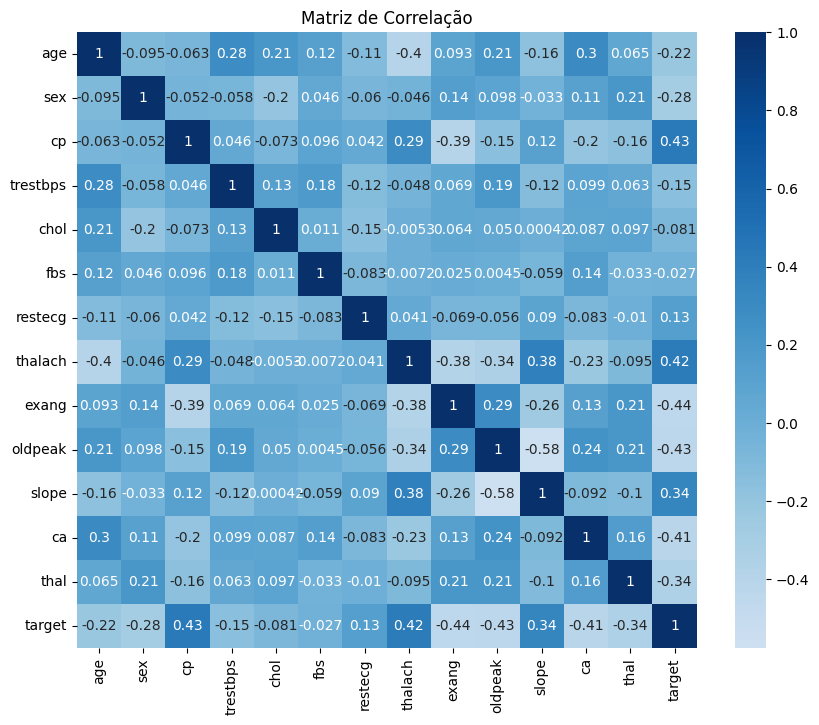

In [26]:
corr = heart_ds.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="Blues", center=0)
plt.title("Matriz de Correlação")
plt.show()

## Modelos de classificação para `target`:

Trata-se de uma classificação binária, então podemos fazer diversos modelos, aqui trataremos desses:
- Regressão Linear
- LDA
- QDA
- Regressão Logística
- KNN
- SVM
- Rede Neural

Por fim faremos a comparação fiel entre os modelos e qual seria mais adequado para essa devida tarefa.

### Regressão Linear (Classificação)

In [12]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

- A ideia da utilizaçao de regressão linear para classificação é tentar prever a variável alvo como uma variável categórica alvo como uma variável contínua e usar um limiar a partir do qual classificaremos o alvo como categórico. Se temos duas classes para prever, uma aproximação:

OLS (apenas diagnóstico) - R² e summary:
R² (train): 0.529
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.529
Model:                            OLS   Adj. R-squared:                  0.485
Method:                 Least Squares   F-statistic:                     11.98
Date:                Mon, 10 Nov 2025   Prob (F-statistic):           6.92e-23
Time:                        20:41:21   Log-Likelihood:                -72.849
No. Observations:                 211   AIC:                             183.7
Df Residuals:                     192   BIC:                             247.4
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

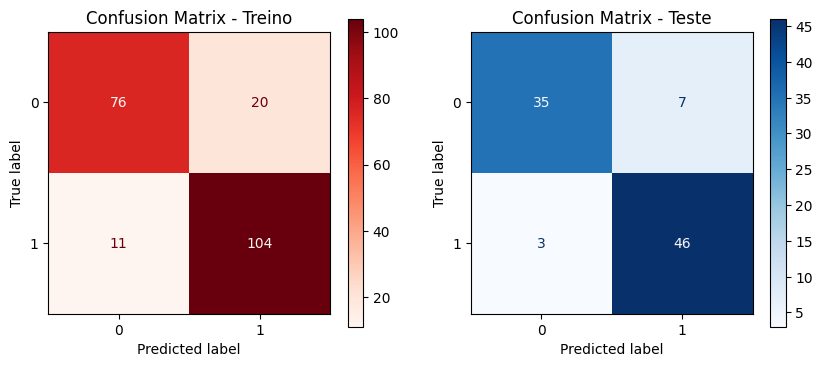

Acurácia no conjunto de treino: 0.853
Acurácia no conjunto de teste: 0.890 


Agora retiramos preditores com p-valor > 0.05 por meio de backward selection
Removendo 'thal_2' com p-valor 0.983
Removendo 'restecg_2' com p-valor 0.889
Removendo 'slope_2' com p-valor 0.828
Removendo 'fbs' com p-valor 0.625
Removendo 'thal_1' com p-valor 0.445
Removendo 'chol' com p-valor 0.376
Removendo 'restecg_1' com p-valor 0.195
Removendo 'exang' com p-valor 0.104
Removendo 'trestbps' com p-valor 0.067
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.506
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     22.90
Date:                Mon, 10 Nov 2025   Prob (F-statistic):           1.41e-26
Time:                        20:41:21   Log-Likelihood:                -77.823
No. Observations:                 2

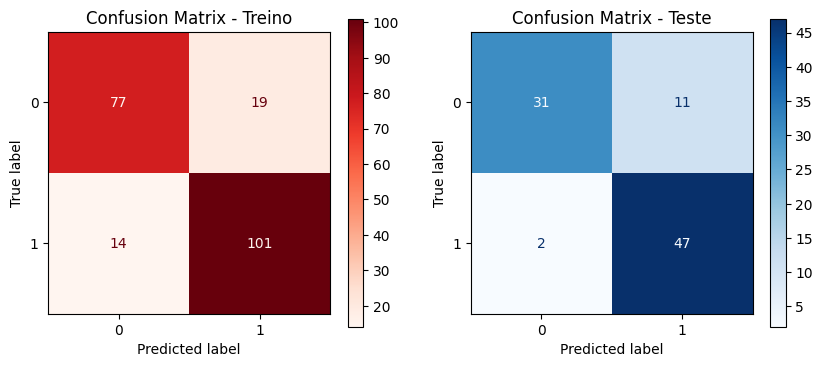

Acurácia no conjunto de treino: 0.844
Acurácia no conjunto de teste: 0.857 




In [13]:
X = heart_ds.drop(["target", "age"], axis=1)
y = heart_ds["target"]

categorical_cols = ['cp', 'thal', 'slope', 'restecg']
categorical_cols = [c for c in categorical_cols if c in X.columns]
if len(categorical_cols) > 0:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

scalizer = StandardScaler() # normaliza os dados e reduz a variancia dos coeficientes
X = pd.DataFrame(scalizer.fit_transform(X), columns=X.columns)

X_const = sm.add_constant(X) # aciciona constante para o intercepto

X_train, X_test, y_train, y_test = train_test_split(X_const, y, test_size=0.3, random_state=200, stratify=y)

X_train = X_train.astype(float)
X_test = X_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)
model_ols = sm.OLS(y_train, X_train).fit()
print("OLS (apenas diagnóstico) - R² e summary:")
print(f"R² (train): {model_ols.rsquared:.3f}")
print(model_ols.summary())
print("\nmatriz de covariância dos coeficientes:")
print(model_ols.cov_params())

y_pred_train = model_ols.predict(X_train)
y_pred_test  = model_ols.predict(X_test)

y_pred_train = np.where(y_pred_train > 0.5, 1, 0)
y_pred_test  = np.where(y_pred_test  > 0.5, 1, 0)

for i in range(len(y_pred_train)):
    if y_pred_train[i] <= 0.5:
        y_pred_train[i] = 0
    else:
        y_pred_train[i] = 1


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm = confusion_matrix(y_train, y_pred_train)
cm_display_train = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
cm_display_train.plot(cmap=plt.cm.Reds, ax=axes[0])
axes[0].set_title("Confusion Matrix - Treino")

for i in range(len(y_pred_test)):
    if y_pred_test[i] <= 0.5:
        y_pred_test[i] = 0
    else:
        y_pred_test[i] = 1

cm = confusion_matrix(y_test, y_pred_test)
cm_display_test = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
cm_display_test.plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Confusion Matrix - Teste")
plt.show()

acc = accuracy_score(y_train, y_pred_train)
print(f"Acurácia no conjunto de treino: {acc:.3f}")
acc = accuracy_score(y_test, y_pred_test)
print(f"Acurácia no conjunto de teste: {acc:.3f} \n\n")

print(f'Agora retiramos preditores com p-valor > 0.05 por meio de backward selection')

X_opt = X_train.copy()
X_opt_test = X_test.copy()
threshold = 0.05

while True:
    model = sm.OLS(y_train, X_opt).fit()
    pvals = model.pvalues.drop("const", errors="ignore")
    worst_pval = pvals.max()
    if worst_pval > threshold:
        worst_var = pvals.idxmax()
        print(f"Removendo '{worst_var}' com p-valor {worst_pval:.3f}")
        X_opt = X_opt.drop(columns=[worst_var])
        X_opt_test = X_opt_test.drop(columns=[worst_var])
    else:
        break

model_final = sm.OLS(y_train, X_opt).fit()

print(model_final.summary())
print("\nmatriz de covariância dos coeficientes:")
print(model_final.cov_params())

y_pred_train = model_final.predict(X_opt)
y_pred_test  = model_final.predict(X_opt_test)

y_pred_train = np.where(y_pred_train > 0.5, 1, 0)
y_pred_test  = np.where(y_pred_test  > 0.5, 1, 0)

for i in range(len(y_pred_train)):
    if y_pred_train[i] <= 0.5:
        y_pred_train[i] = 0
    else:
        y_pred_train[i] = 1


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm = confusion_matrix(y_train, y_pred_train)
cm_display_train = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
cm_display_train.plot(cmap=plt.cm.Reds, ax=axes[0])
axes[0].set_title("Confusion Matrix - Treino")

for i in range(len(y_pred_test)):
    if y_pred_test[i] <= 0.5:
        y_pred_test[i] = 0
    else:
        y_pred_test[i] = 1

cm = confusion_matrix(y_test, y_pred_test)
cm_display_test = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
cm_display_test.plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Confusion Matrix - Teste")
plt.show()

acc = accuracy_score(y_train, y_pred_train)
print(f"Acurácia no conjunto de treino: {acc:.3f}")
acc = accuracy_score(y_test, y_pred_test)
print(f"Acurácia no conjunto de teste: {acc:.3f} \n\n")


Podemos ver que após o `backward selection`, as variâncias dos estimadores em geral diminuiu devido à remoçao de algumas variáveis que apresentavam dependências lineares entre si. 

Para comparar nosso modelo com outros, é importante obter uma estimativa mais robustas de seu desempenho médio.

Para isso, utilizaremos a validação cruzada `(cross-validation)`, aplicando a regressão linear em cinco divisões `(5-folds)` diferentes dos dados.

Esse método fornece uma estimativa mais confiável da performance média do modelo, pois reduz a influência da divisão específica dos dados em treino e teste, além de representar melhor sua capacidade de generalização ou seja, o risco de erro ao aplicar o modelo em novos dados.

Removendo 'restecg_2' com p-valor 0.983
Removendo 'slope_2' com p-valor 0.700
Removendo 'fbs' com p-valor 0.567
Removendo 'thal_1' com p-valor 0.443
Removendo 'thal_3' com p-valor 0.981
Removendo 'exang' com p-valor 0.437
Removendo 'cp_3' com p-valor 0.295
Removendo 'chol' com p-valor 0.291
Removendo 'slope_1' com p-valor 0.221
Removendo 'cp_1' com p-valor 0.068
Removendo 'trestbps' com p-valor 0.059


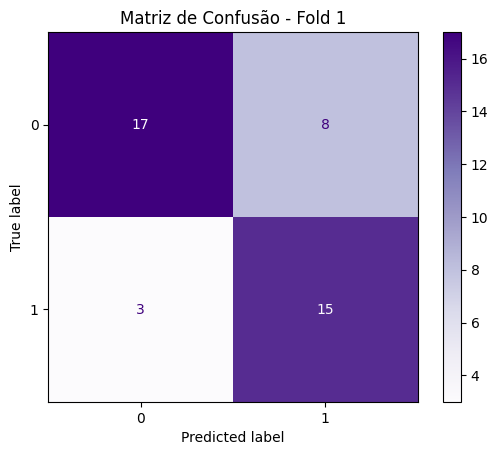

Fold 1 - Acc: 0.744 | Prec: 0.652 | Rec: 0.833 | F1: 0.732
Removendo 'restecg_2' com p-valor 0.833
Removendo 'thal_2' com p-valor 0.824
Removendo 'thal_1' com p-valor 0.870
Removendo 'slope_2' com p-valor 0.813
Removendo 'fbs' com p-valor 0.523
Removendo 'exang' com p-valor 0.246
Removendo 'trestbps' com p-valor 0.207
Removendo 'chol' com p-valor 0.100


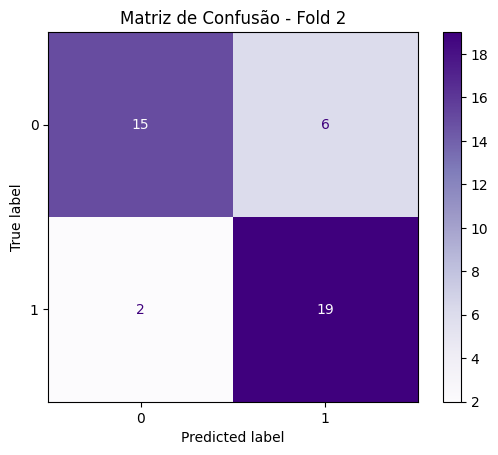

Fold 2 - Acc: 0.810 | Prec: 0.760 | Rec: 0.905 | F1: 0.826
Removendo 'thal_2' com p-valor 0.804
Removendo 'restecg_2' com p-valor 0.600
Removendo 'thal_1' com p-valor 0.503
Removendo 'slope_2' com p-valor 0.471
Removendo 'chol' com p-valor 0.425
Removendo 'cp_3' com p-valor 0.420
Removendo 'trestbps' com p-valor 0.446
Removendo 'cp_2' com p-valor 0.308
Removendo 'cp_1' com p-valor 0.294
Removendo 'restecg_1' com p-valor 0.170
Removendo 'fbs' com p-valor 0.115
Removendo 'slope_1' com p-valor 0.074
Removendo 'fbs' com p-valor 0.115
Removendo 'slope_1' com p-valor 0.074


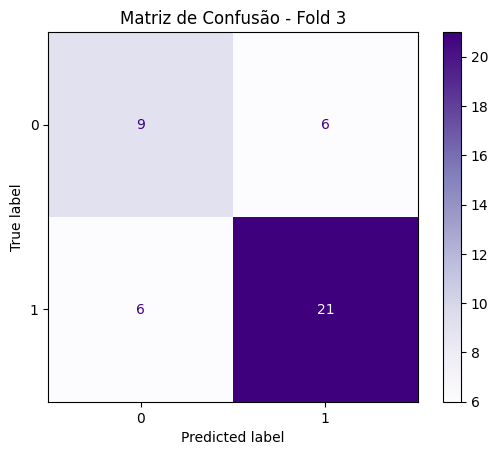

Fold 3 - Acc: 0.714 | Prec: 0.778 | Rec: 0.778 | F1: 0.778
Removendo 'thal_1' com p-valor 0.942
Removendo 'restecg_2' com p-valor 0.862
Removendo 'slope_2' com p-valor 0.709
Removendo 'thal_3' com p-valor 0.685
Removendo 'fbs' com p-valor 0.678
Removendo 'chol' com p-valor 0.560
Removendo 'trestbps' com p-valor 0.423
Removendo 'restecg_1' com p-valor 0.217
Removendo 'thalach' com p-valor 0.161
Removendo 'thal_2' com p-valor 0.103
Removendo 'cp_1' com p-valor 0.063
Removendo 'thal_2' com p-valor 0.103
Removendo 'cp_1' com p-valor 0.063


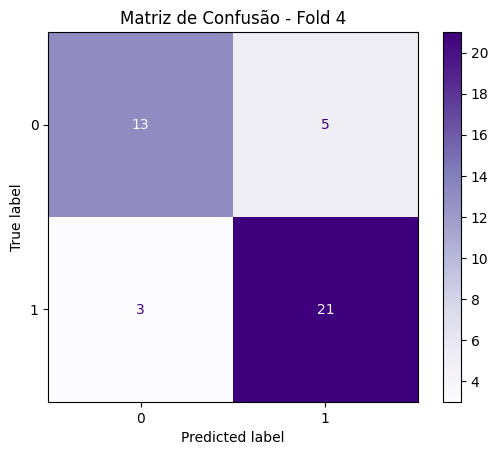

Fold 4 - Acc: 0.810 | Prec: 0.808 | Rec: 0.875 | F1: 0.840
Removendo 'thal_3' com p-valor 0.979
Removendo 'restecg_2' com p-valor 0.974
Removendo 'slope_2' com p-valor 0.893
Removendo 'thal_1' com p-valor 0.896
Removendo 'fbs' com p-valor 0.850
Removendo 'restecg_1' com p-valor 0.806
Removendo 'chol' com p-valor 0.696
Removendo 'thalach' com p-valor 0.422
Removendo 'thal_2' com p-valor 0.324
Removendo 'thal_1' com p-valor 0.896
Removendo 'fbs' com p-valor 0.850
Removendo 'restecg_1' com p-valor 0.806
Removendo 'chol' com p-valor 0.696
Removendo 'thalach' com p-valor 0.422
Removendo 'thal_2' com p-valor 0.324
Removendo 'trestbps' com p-valor 0.145
Removendo 'exang' com p-valor 0.070
Removendo 'trestbps' com p-valor 0.145
Removendo 'exang' com p-valor 0.070


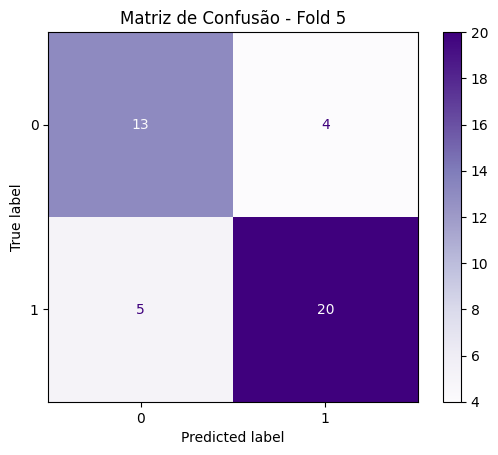

Fold 5 - Acc: 0.786 | Prec: 0.833 | Rec: 0.800 | F1: 0.816

Acurácias por fold: [0.7441860465116279, 0.8095238095238095, 0.7142857142857143, 0.8095238095238095, 0.7857142857142857]
Acurácia média: 0.773 ± 0.038
Precisões por fold: [0.6521739130434783, 0.76, 0.7777777777777778, 0.8076923076923077, 0.8333333333333334]
Precisão média: 0.766 ± 0.062
Recalls por fold: [0.8333333333333334, 0.9047619047619048, 0.7777777777777778, 0.875, 0.8]
Recall médio: 0.838 ± 0.047
F1 por fold: [0.7317073170731707, 0.8260869565217391, 0.7777777777777778, 0.84, 0.8163265306122449]
F1 médio: 0.798 ± 0.039
Usando os dados de y_test como dados de validação final:
Acurácia (final): 0.857
Precisão (final): 0.810
Recall (final): 0.959
F1 (final): 0.879


In [15]:
kf = KFold(n_splits=5, shuffle=True, random_state=360)

# listas para métricas por fold
accuracies = []
precisions = []
recalls = []
f1s = []
fold = 1

# garantir índices e tipos alinhados
y_opt = y_train.reset_index(drop=True).astype(float)
X_opt = X_train.reset_index(drop=True).astype(float)

for train_index, test_index in kf.split(X_opt):
    X_train_cv = X_opt.iloc[train_index].reset_index(drop=True)
    X_test_cv  = X_opt.iloc[test_index].reset_index(drop=True)
    y_train_cv = y_opt.iloc[train_index].reset_index(drop=True)
    y_test_cv  = y_opt.iloc[test_index].reset_index(drop=True)

    # adiciona constante apenas se necessário (não duplica se já existir)
    X_train_const = sm.add_constant(X_train_cv)
    X_test_const  = sm.add_constant(X_test_cv)

    # backward selection dentro do fold
    threshold = 0.05
    selected_X_train = X_train_const.copy()
    selected_X_test = X_test_const.copy()

    while True:
        model_cv = sm.OLS(y_train_cv, selected_X_train).fit()
        pvals = model_cv.pvalues.drop("const", errors="ignore")
        if pvals.empty:
            break
        worst_var = pvals.idxmax()
        worst_pval = pvals.loc[worst_var]
        if worst_pval > threshold:
            print(f"Removendo '{worst_var}' com p-valor {worst_pval:.3f}")
            selected_X_train = selected_X_train.drop(columns=[worst_var])
            selected_X_test = selected_X_test.drop(columns=[worst_var])
        else:
            break

    # ajusta o modelo do fold com os preditores selecionados
    model_fold = sm.OLS(y_train_cv, selected_X_train).fit()

    # previsões e binarização por limiar 0.5
    y_pred = model_fold.predict(selected_X_test)
    y_pred_binary = (y_pred > 0.5).astype(int)

    # métricas
    acc = accuracy_score(y_test_cv, y_pred_binary)
    prec = precision_score(y_test_cv, y_pred_binary, zero_division=0)
    rec = recall_score(y_test_cv, y_pred_binary, zero_division=0)
    f1 = f1_score(y_test_cv, y_pred_binary, zero_division=0)

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

    # matriz de confusão do fold
    cm = confusion_matrix(y_test_cv, y_pred_binary)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Purples)
    plt.title(f"Matriz de Confusão - Fold {fold}")
    plt.show()

    print(f"Fold {fold} - Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | F1: {f1:.3f}")
    fold += 1

# resumo por métrica (média ± std)
print()
print(f"Acurácias por fold: {accuracies}")
print(f"Acurácia média: {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Precisões por fold: {precisions}")
print(f"Precisão média: {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
print(f"Recalls por fold: {recalls}")
print(f"Recall médio: {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
print(f"F1 por fold: {f1s}")
print(f"F1 médio: {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")

# Avaliação final no conjunto de teste reservado (modelo final obtido pelo backward selection global)
print('Usando os dados de y_test como dados de validação final:')
y_pred = model_final.predict(X_opt_test)
y_pred_binary = (y_pred > 0.5).astype(int)
acc_final = accuracy_score(y_test, y_pred_binary)
prec_final = precision_score(y_test, y_pred_binary, zero_division=0)
rec_final = recall_score(y_test, y_pred_binary, zero_division=0)
f1_final = f1_score(y_test, y_pred_binary, zero_division=0)
print(f"Acurácia (final): {acc_final:.3f}")
print(f"Precisão (final): {prec_final:.3f}")
print(f"Recall (final): {rec_final:.3f}")
print(f"F1 (final): {f1_final:.3f}")

Podemos ver que nosso modelo de regressão linear apesenta um recall bastante alto. As principais metrica usada para classificar modelo aqui será o recall e acuracia, pois a acuracia representa a porcentagem de acertos em relaçao ao total de classificacoes do modelo, enquanto o recall mede a taxa de positivos capturados pelo modelo em relaçao ao total de positivos nos dados. Isso e importante principalmente e identificaçao de doenças, já que um dos erros mais graves no campo de diagnósticos é nao consegui identificar uma doençao em um indivíduo doente.

## LDA - Análise Linear Discriminante

Após a abordagem inicial com a Regressão Linear como um classificador, passaremos agora para a Análise Linear Discriminante (LDA), um método que modela a classificação de maneira inerentemente estatística e mais robusta.

LDA é um algoritmo que assume que os dados de cada classe seguem uma distribuição Gaussiana (Normal) e que todas as classes compartilham da mesma matriz de covariância (ou seja, a mesma dispersão). A ideia central é:

Projetar os Dados: Encontrar um eixo (ou subespaço) que maximize a separação entre as médias das classes e minimize a variação dentro de cada classe.

Decisão: Classificar um novo ponto de dados na classe cuja média, ele está mais próximo após a projeção.

A principal vantagem do LDA é a sua capacidade de reduzir a dimensionalidade enquanto otimiza a separação entre as classes, tornando-o um classificador linear eficiente e interpretável. Para garantir a validade estatística do modelo, o Standard Scaling das variáveis contínuas é um passo obrigatório, pois o LDA é sensível à escala das variáveis

AVALIAÇÃO DO LDA NO CONJUNTO DE TESTE (30%)
-------------------------------------------
Acurácia : 0.791
Precisão : 0.788
Sensibilidade: 0.837
--------------------------------------------


<Figure size 600x600 with 0 Axes>

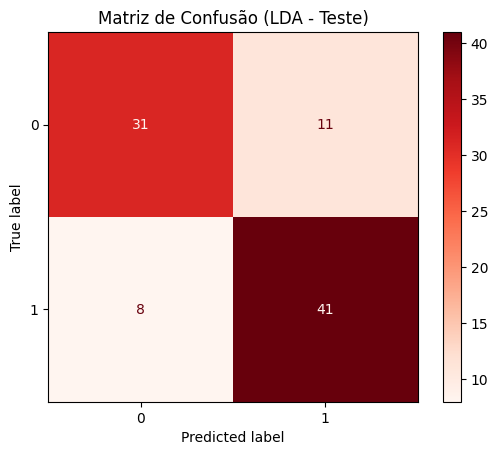

Matriz de Confusão (LDA - Treino)
Acurácia Treino: 0.877


<Figure size 600x600 with 0 Axes>

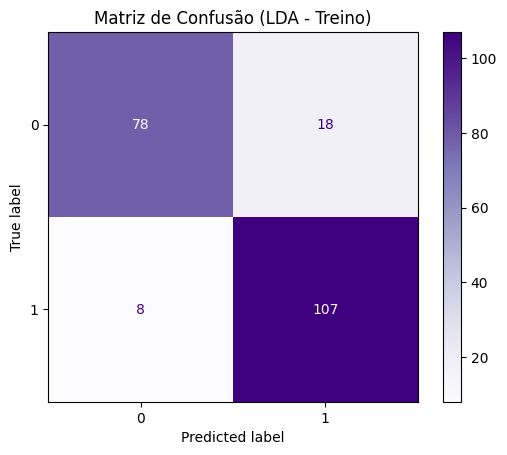

3. VALIDAÇÃO CRUZADA 5-FOLD PARA LDA (KFold)
--------------------------------------------
Fold 1 - Acurácia: 0.754 | Precisão: 0.694 | Recall: 0.862


<Figure size 600x600 with 0 Axes>

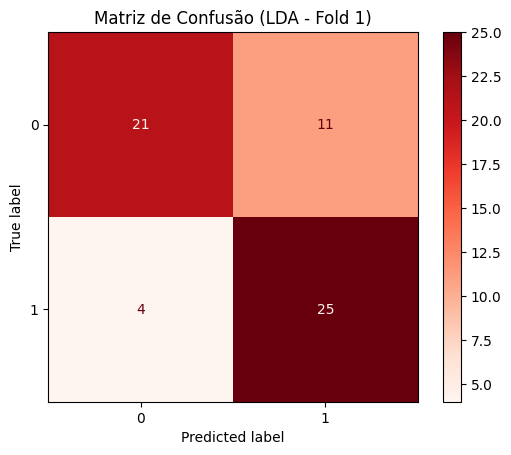

Fold 2 - Acurácia: 0.803 | Precisão: 0.778 | Recall: 0.875



<Figure size 600x600 with 0 Axes>

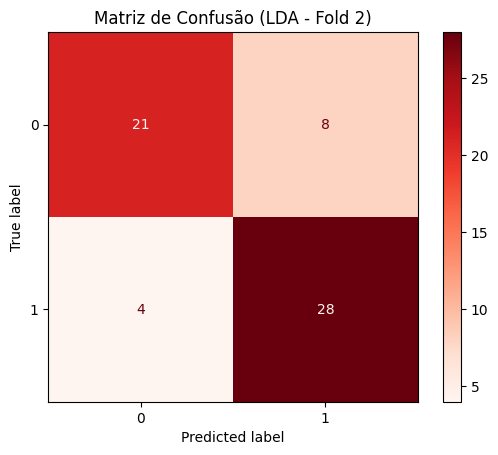

Fold 3 - Acurácia: 0.867 | Precisão: 0.872 | Recall: 0.919


<Figure size 600x600 with 0 Axes>

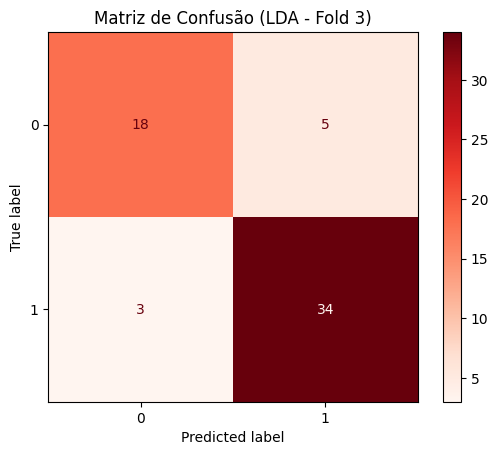

Fold 4 - Acurácia: 0.800 | Precisão: 0.889 | Recall: 0.727


<Figure size 600x600 with 0 Axes>

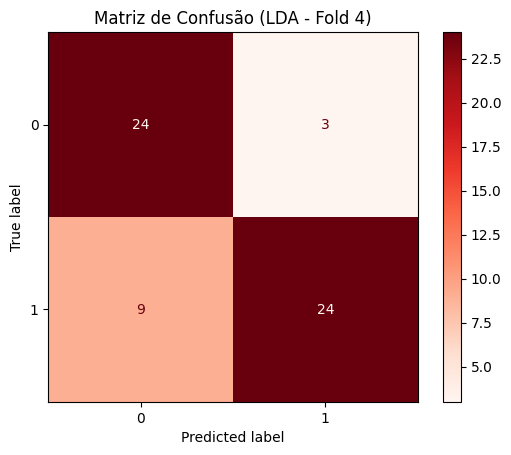

Fold 5 - Acurácia: 0.833 | Precisão: 0.795 | Recall: 0.939


<Figure size 600x600 with 0 Axes>

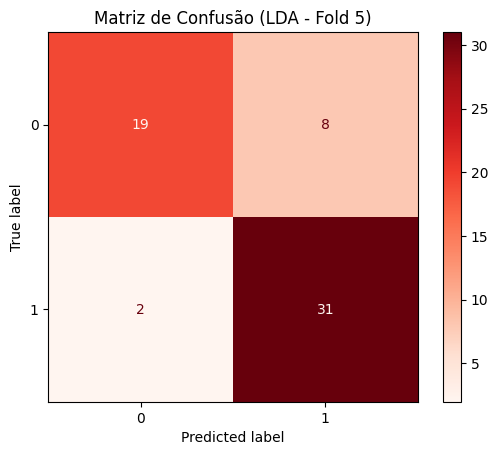


-------------------------------------------------------
--- RESUMO FINAL DA VALIDAÇÃO CRUZADA (LDA) ---
Acurácia Média:  0.811 ± 0.037
Precisão Média:  0.806 ± 0.070
Recall Médio:    0.865 ± 0.074
-------------------------------------------------------


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Separar Features (X) e Target (y)
X = heart_ds.drop("target", axis=1)
y = heart_ds["target"]

# 1.1. Identificar colunas e realizar One-Hot Encoding
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['cp', 'thal', 'slope', 'restecg'] 

# Aplica One-Hot Encoding nas colunas categóricas
if len(categorical_cols) > 0:
    X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)
else:
    X_encoded = X.copy()

# 1.2. Aplicar Standard Scaling APENAS nas colunas contínuas
# Identifica quais colunas contínuas persistem após o encoding (todas devem persistir)
cols_to_scale = [col for col in continuous_cols if col in X_encoded.columns]

scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

# 1.3. Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

#TREINAMENTO E AVALIAÇÃO DO LDA NO CONJUNTO DE TESTE 

model_lda = LDA()
model_lda.fit(X_train, y_train)
y_pred_lda = model_lda.predict(X_test)

# Métricas LDA
acc_lda = accuracy_score(y_test, y_pred_lda)
precision_lda = precision_score(y_test, y_pred_lda)
recall_lda = recall_score(y_test, y_pred_lda)


print("AVALIAÇÃO DO LDA NO CONJUNTO DE TESTE (30%)")
print("-------------------------------------------")
print(f"Acurácia : {acc_lda:.3f}")
print(f"Precisão : {precision_lda:.3f}")
print(f"Sensibilidade: {recall_lda:.3f}")
print("--------------------------------------------")

# Matriz de Confusão para o Teste
cm_lda = confusion_matrix(y_test, y_pred_lda)
cm_display_lda = ConfusionMatrixDisplay(confusion_matrix=cm_lda, display_labels=[0, 1])

plt.figure(figsize=(6, 6))
cm_display_lda.plot(cmap='Reds', values_format='d')
plt.title("Matriz de Confusão (LDA - Teste)")
plt.show() 

#3. VALIDAÇÃO CRUZADA (KFOLD) PARA AVALIAÇÃO ROBUSTA

kf = KFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []
precisions = []
recalls = []
fold = 1

y_pred_train_lda = model_lda.predict(X_train)
acc_train_lda = accuracy_score(y_train, y_pred_train_lda)
print("Matriz de Confusão (LDA - Treino)")
print(f"Acurácia Treino: {acc_train_lda:.3f}")
cm_train_lda = confusion_matrix(y_train, y_pred_train_lda)
cm_display_train_lda = ConfusionMatrixDisplay(confusion_matrix=cm_train_lda, display_labels=[0, 1])

plt.figure(figsize=(6, 6))
cm_display_train_lda.plot(cmap='Purples', values_format='d')
plt.title("Matriz de Confusão (LDA - Treino)")
plt.show()



print("3. VALIDAÇÃO CRUZADA 5-FOLD PARA LDA (KFold)")
print("--------------------------------------------")

# Usando o dataset completo e pré-processado para o KFold
X_cv = X_scaled.copy()
y_cv = y.copy()



for train_index, test_index in kf.split(X_cv):
    X_train_fold, X_test_fold = X_cv.iloc[train_index], X_cv.iloc[test_index]
    y_train_fold, y_test_fold = y_cv.iloc[train_index], y_cv.iloc[test_index]

    # Treinar o LDA em cada Fold
    model_lda_cv = LDA()
    model_lda_cv.fit(X_train_fold, y_train_fold)
    y_pred_cv = model_lda_cv.predict(X_test_fold)

    # Armazenar Métricas
    acc = accuracy_score(y_test_fold, y_pred_cv)
    prec = precision_score(y_test_fold, y_pred_cv)
    rec = recall_score(y_test_fold, y_pred_cv)
    
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)

    print(f"Fold {fold} - Acurácia: {acc:.3f} | Precisão: {prec:.3f} | Recall: {rec:.3f}")
    
    # Matriz de Confusão para cada Fold (para replicar seu formato)
    cm_fold = confusion_matrix(y_test_fold, y_pred_cv)
    disp_fold = ConfusionMatrixDisplay(confusion_matrix=cm_fold, display_labels=[0, 1])
    
    plt.figure(figsize=(6, 6))
    disp_fold.plot(cmap='Reds', values_format='d')
    plt.title(f"Matriz de Confusão (LDA - Fold {fold})")
    plt.show() # O equivalente a salvar e mostrar no seu ambiente
    
    fold += 1

# Matriz de Confusão para o Treino


# Resumo da Validação Cruzada
print("\n-------------------------------------------------------")
print("--- RESUMO FINAL DA VALIDAÇÃO CRUZADA (LDA) ---")
print(f"Acurácia Média:  {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Precisão Média:  {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
print(f"Recall Médio:    {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
print("-------------------------------------------------------")

### QDA - Análise Quadrática Discriminante

A Análise Quadrática Discriminante (QDA) é a progressão natural da Análise Linear Discriminante (LDA). Enquanto o LDA assume que todas as classes compartilham a mesma matriz de covariância (ou seja, a dispersão dos dados é idêntica para todas as classes), o QDA relaxa essa suposição

RESUMO DO QDA (Análise de Meios e Covariâncias)
-----------------------------------------------
Média das Features por Classe:
           Classe 0 (Ausente)  Classe 1 (Presente)
age                     0.192               -0.204
sex                     0.812                0.530
trestbps                0.145               -0.113
chol                    0.118               -0.091
fbs                     0.177                0.113
thalach                -0.369                0.503
exang                   0.500                0.113
oldpeak                 0.400               -0.426
ca                      1.250                0.409
cp_1                    0.073                0.270
cp_2                    0.104                0.452
cp_3                    0.042                0.104
thal_1                  0.083                0.035
thal_2                  0.260                0.800
thal_3                  0.646                0.157
slope_1                 0.604                0.296
slope_

<Figure size 600x600 with 0 Axes>

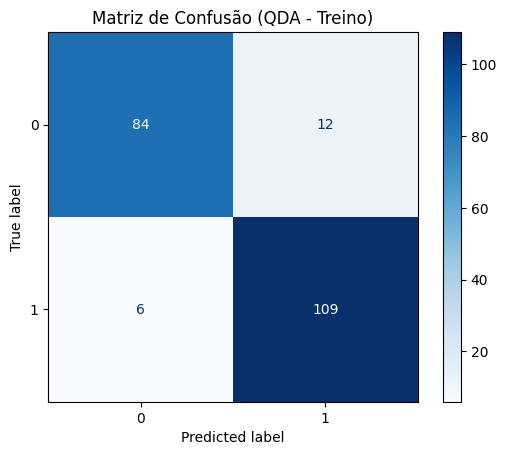

3. AVALIAÇÃO DO QDA NO CONJUNTO DE TESTE (30%)
Acurácia : 0.791
Precisão : 0.841
Sensibilidade: 0.755
----------------------------------------------


<Figure size 600x600 with 0 Axes>

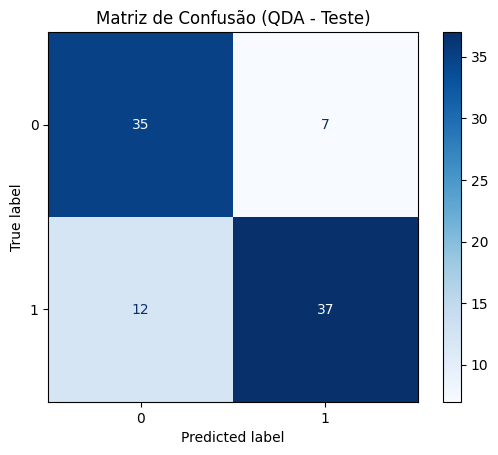

VALIDAÇÃO CRUZADA 5-FOLD PARA QDA (KFold)
-----------------------------------------
Fold 1 - Acurácia: 0.770 | Precisão: 0.759 | Sensibilidade : 0.759


<Figure size 600x600 with 0 Axes>

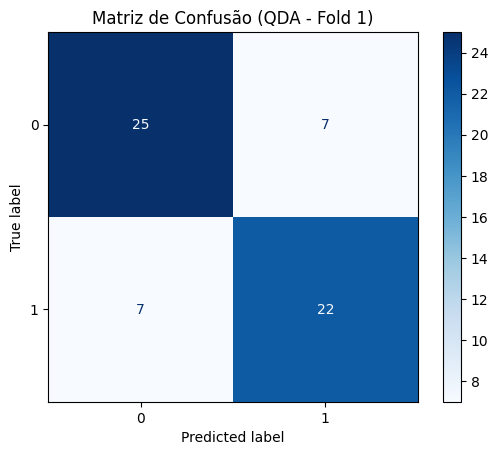

Fold 2 - Acurácia: 0.836 | Precisão: 0.824 | Sensibilidade : 0.875


<Figure size 600x600 with 0 Axes>

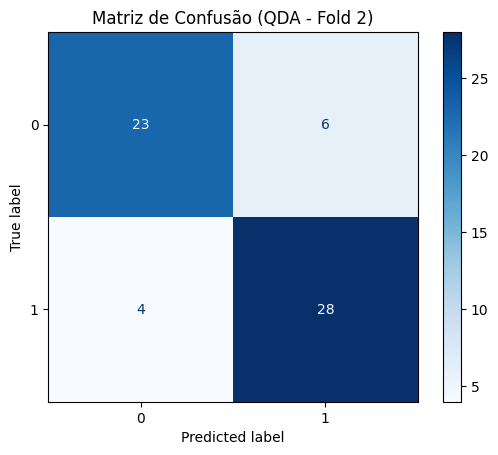

Fold 3 - Acurácia: 0.817 | Precisão: 0.861 | Sensibilidade : 0.838


<Figure size 600x600 with 0 Axes>

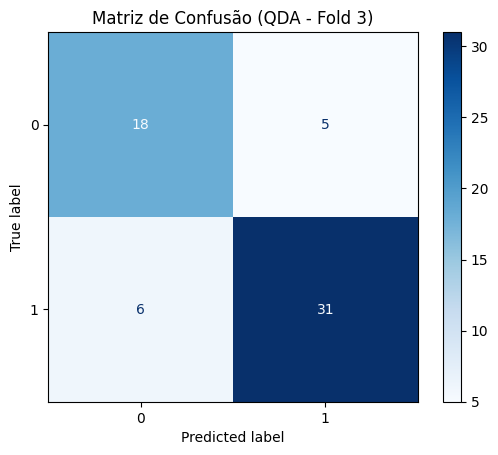

Fold 4 - Acurácia: 0.800 | Precisão: 0.920 | Sensibilidade : 0.697


<Figure size 600x600 with 0 Axes>

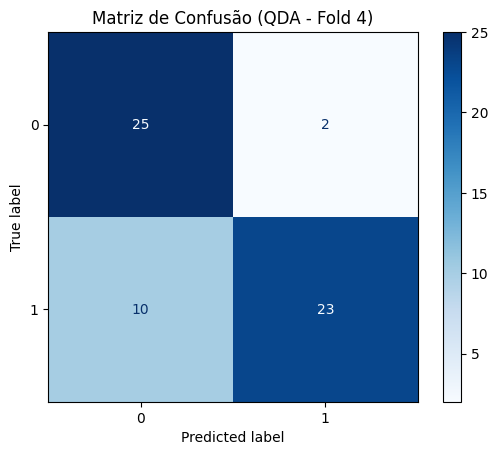

Fold 5 - Acurácia: 0.800 | Precisão: 0.800 | Sensibilidade : 0.848


<Figure size 600x600 with 0 Axes>

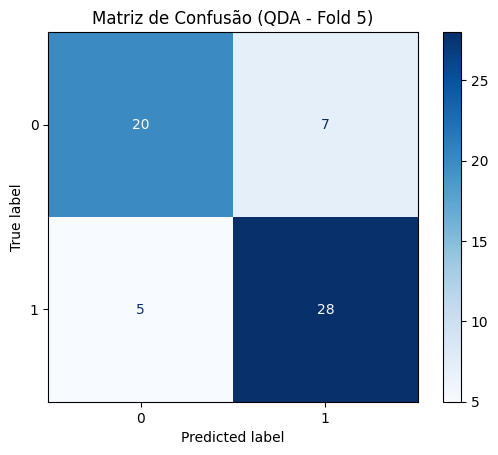

RESUMO FINAL DA VALIDAÇÃO CRUZADA (QDA)
Acurácia Média:  0.805 ± 0.022
Precisão Média:  0.833 ± 0.055
Recall Médio:    0.803 ± 0.066
-------------------------------------------------------


In [17]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay




# Separar Features (X) e Target (y)
X = heart_ds.drop("target", axis=1)
y = heart_ds["target"]

# One-Hot Encoding
categorical_cols = ['cp', 'thal', 'slope', 'restecg'] 
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

# Standard Scaling (Crucial para QDA, assim como para LDA)
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cols_to_scale = [col for col in continuous_cols if col in X_encoded.columns]
scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

# Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Os tipos de dados são mantidos em float para coerência
X_train = X_train.astype(float)
X_test = X_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)


# TREINAMENTO DO QDA E VISUALIZAÇÃO DE COMPONENTES 

model_qda = QDA(reg_param=0.1, priors=[0.5])  # regularização para estabilidade
model_qda.fit(X_train, y_train)

# NOTA: QDA não tem um atributo 'coef_' simples como o LDA ou OLS. 
# Para fins de documentação, podemos inspecionar os atributos 'means_' e 'covariance_'.

print("RESUMO DO QDA (Análise de Meios e Covariâncias)")
print("-----------------------------------------------")

# Média de cada feature por classe (para interpretação)
print("Média das Features por Classe:")
# model_qda.means_ contém as médias das features. A primeira linha é Classe 0, a segunda é Classe 1.
means_summary = pd.DataFrame(model_qda.means_, 
                             columns=X_train.columns, 
                             index=['Classe 0 (Ausente)', 'Classe 1 (Presente)'])

# Transpõe para melhor visualização
print(means_summary.T.to_string(float_format="%.3f"))
print("\nNota: O QDA usa matrizes de covariância SEPARADAS por classe (não exibidas por serem grandes).")



# 2. AVALIAÇÃO DO QDA NO CONJUNTO DE TREINO

y_pred_train_qda = model_qda.predict(X_train)
acc_train_qda = accuracy_score(y_train, y_pred_train_qda)


print("2. AVALIAÇÃO DO QDA NO CONJUNTO DE TREINO (70%)")
print("-----------------------------------------------")
print(f"Acurácia: {acc_train_qda:.3f}")

# Matriz de Confusão para o Treino
cm_train_qda = confusion_matrix(y_train, y_pred_train_qda)
cm_display_train_qda = ConfusionMatrixDisplay(confusion_matrix=cm_train_qda, display_labels=[0, 1])

plt.figure(figsize=(6, 6))
cm_display_train_qda.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusão (QDA - Treino)")
plt.show()


#AVALIAÇÃO DO QDA NO CONJUNTO DE TESTE

y_pred_test_qda = model_qda.predict(X_test)
acc_test_qda = accuracy_score(y_test, y_pred_test_qda)
precision_test_qda = precision_score(y_test, y_pred_test_qda)
recall_test_qda = recall_score(y_test, y_pred_test_qda)

print("3. AVALIAÇÃO DO QDA NO CONJUNTO DE TESTE (30%)")

print(f"Acurácia : {acc_test_qda:.3f}")
print(f"Precisão : {precision_test_qda:.3f}")
print(f"Sensibilidade: {recall_test_qda:.3f}")
print("----------------------------------------------")

# Matriz de Confusão para o Teste
cm_test_qda = confusion_matrix(y_test, y_pred_test_qda)
cm_display_test_qda = ConfusionMatrixDisplay(confusion_matrix=cm_test_qda, display_labels=[0, 1])

plt.figure(figsize=(6, 6))
cm_display_test_qda.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusão (QDA - Teste)")
plt.show()

# --- 4. VALIDAÇÃO CRUZADA (KFOLD) PARA AVALIAÇÃO ROBUSTA ---

kf = KFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []
precisions = []
recalls = []
fold = 1


print("VALIDAÇÃO CRUZADA 5-FOLD PARA QDA (KFold)")
print("-----------------------------------------")

X_cv = X_scaled.copy()
y_cv = y.copy()

for train_index, test_index in kf.split(X_cv):
    X_train_fold, X_test_fold = X_cv.iloc[train_index], X_cv.iloc[test_index]
    y_train_fold, y_test_fold = y_cv.iloc[train_index], y_cv.iloc[test_index]

    model_qda_cv = QDA(reg_param=0.1, priors=[0.5])
    model_qda_cv.fit(X_train_fold, y_train_fold)
    y_pred_cv = model_qda_cv.predict(X_test_fold)

    acc = accuracy_score(y_test_fold, y_pred_cv)
    prec = precision_score(y_test_fold, y_pred_cv)
    rec = recall_score(y_test_fold, y_pred_cv)
    
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)

    print(f"Fold {fold} - Acurácia: {acc:.3f} | Precisão: {prec:.3f} | Sensibilidade : {rec:.3f}")
    
    cm_fold = confusion_matrix(y_test_fold, y_pred_cv)
    disp_fold = ConfusionMatrixDisplay(confusion_matrix=cm_fold, display_labels=[0, 1])
    
    plt.figure(figsize=(6, 6))
    disp_fold.plot(cmap='Blues', values_format='d')
    plt.title(f"Matriz de Confusão (QDA - Fold {fold})")
    plt.show()
    
    fold += 1

# Resumo da Validação Cruzada

print("RESUMO FINAL DA VALIDAÇÃO CRUZADA (QDA)")
print(f"Acurácia Média:  {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Precisão Média:  {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
print(f"Recall Médio:    {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
print("-------------------------------------------------------")

### Regressão Logística

Logistic Regression (baseline):
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  211
Model:                          Logit   Df Residuals:                      191
Method:                           MLE   Df Model:                           19
Date:                Mon, 10 Nov 2025   Pseudo R-squ.:                  0.4980
Time:                        20:42:50   Log-Likelihood:                -72.989
converged:                      False   LL-Null:                       -145.40
Covariance Type:            nonrobust   LLR p-value:                 2.179e-21
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.4787   1.57e+05      0.000      1.000   -3.08e+05    3.08e+05
age           -0.0878      0.254     -0.346      0.729      -0.585       0.409
sex           -2.254

/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


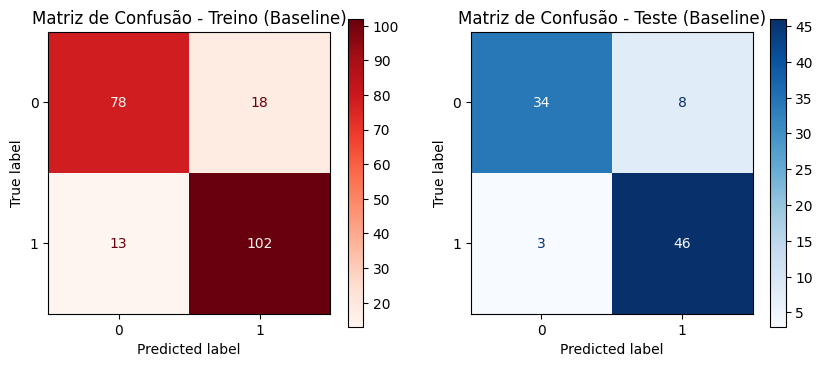

Baseline Treino: Acc=0.853 | Prec=0.850 | Rec=0.887 | F1=0.868
Baseline Teste : Acc=0.879 | Prec=0.852 | Rec=0.939 | F1=0.893

Backward Selection (p-valor > 0.05) no treino:
Removendo 'thal_2' com p-valor 1.000
Removendo 'restecg_2' com p-valor 0.980
Removendo 'thal_1' com p-valor 0.922
Removendo 'age' com p-valor 0.728
Removendo 'slope_2' com p-valor 0.684
Removendo 'fbs' com p-valor 0.426
Removendo 'chol' com p-valor 0.333
Removendo 'restecg_1' com p-valor 0.203
Removendo 'thalach' com p-valor 0.171
Removendo 'thal_3' com p-valor 0.181
Removendo 'trestbps' com p-valor 0.081
Removendo 'cp_1' com p-valor 0.077

Resumo do modelo após Backward Selection:
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  211
Model:                          Logit   Df Residuals:                      203
Method:                           MLE   Df Model:                            7
Date:                Mo

/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


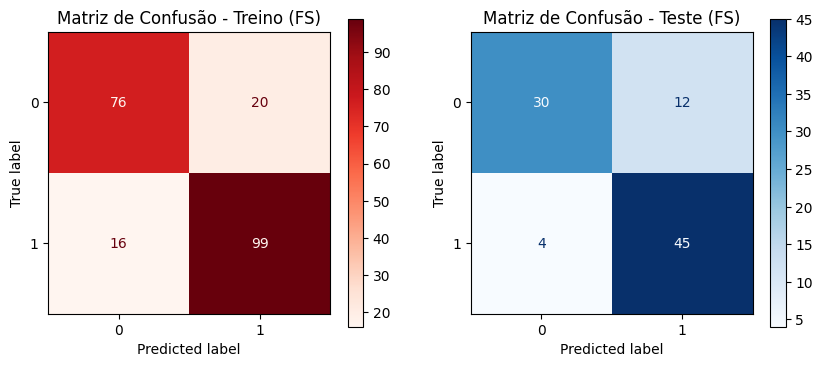

Final Treino: Acc=0.829 | Prec=0.832 | Rec=0.861 | F1=0.846
Final Teste : Acc=0.824 | Prec=0.789 | Rec=0.918 | F1=0.849


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import statsmodels.api as sm

# 1) Preparação dos dados: One-Hot Encoding e Normalização
X = heart_ds.drop("target", axis=1)
y = heart_ds["target"].astype(int)

categorical_cols = ['cp', 'thal', 'slope', 'restecg']
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# One-Hot
X_encoded = pd.get_dummies(X, columns=[c for c in categorical_cols if c in X.columns], drop_first=True, dtype=int)

# Scale APENAS contínuas
cols_to_scale = [c for c in continuous_cols if c in X_encoded.columns]
scaler = StandardScaler()
X_scaled = X_encoded.copy()
if len(cols_to_scale) > 0:
    X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

# Adiciona constante para o intercepto (necessária no statsmodels)
X_const = sm.add_constant(X_scaled)

# 2) Divisão Treino/Teste estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X_const, y, test_size=0.3, random_state=200, stratify=y
)

# 3) LOGIT baseline (sem seleção)
logit_base = sm.Logit(y_train, X_train)
model_logit_base = logit_base.fit(disp=False, maxiter=200)
print("Logistic Regression (baseline):")
print(model_logit_base.summary())

# Avaliação baseline
proba_train = model_logit_base.predict(X_train)
proba_test  = model_logit_base.predict(X_test)

y_pred_train = (proba_train > 0.5).astype(int)
y_pred_test  = (proba_test  > 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm_tr = confusion_matrix(y_train, y_pred_train)
ConfusionMatrixDisplay(cm_tr, display_labels=[0,1]).plot(cmap=plt.cm.Reds, ax=axes[0])
axes[0].set_title("Matriz de Confusão - Treino (Baseline)")
cm_te = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm_te, display_labels=[0,1]).plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Matriz de Confusão - Teste (Baseline)")
plt.show()

print(f"Baseline Treino: Acc={accuracy_score(y_train, y_pred_train):.3f} | Prec={precision_score(y_train, y_pred_train):.3f} | Rec={recall_score(y_train, y_pred_train):.3f} | F1={f1_score(y_train, y_pred_train):.3f}")
print(f"Baseline Teste : Acc={accuracy_score(y_test, y_pred_test):.3f} | Prec={precision_score(y_test, y_pred_test):.3f} | Rec={recall_score(y_test, y_pred_test):.3f} | F1={f1_score(y_test, y_pred_test):.3f}")

# 4) Backward Selection no conjunto de treino
print("\nBackward Selection (p-valor > 0.05) no treino:")
X_opt = X_train.copy()
X_opt_test = X_test.copy()
threshold = 0.05

while True:
    model_tmp = sm.Logit(y_train, X_opt).fit(disp=False, maxiter=200)
    pvals = model_tmp.pvalues.drop("const", errors="ignore")
    if pvals.empty:
        break
    worst_var = pvals.idxmax()
    worst_pval = pvals.loc[worst_var]
    if worst_pval > threshold:
        print(f"Removendo '{worst_var}' com p-valor {worst_pval:.3f}")
        X_opt = X_opt.drop(columns=[worst_var])
        X_opt_test = X_opt_test.drop(columns=[worst_var])
    else:
        break

model_logit_final = sm.Logit(y_train, X_opt).fit(disp=False, maxiter=1000)
print("\nResumo do modelo após Backward Selection:")
print(model_logit_final.summary())

# Avaliação final (treino/teste)
proba_train_fs = model_logit_final.predict(X_opt)
proba_test_fs  = model_logit_final.predict(X_opt_test)

y_pred_train_fs = (proba_train_fs > 0.5).astype(int)
y_pred_test_fs  = (proba_test_fs  > 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm_tr = confusion_matrix(y_train, y_pred_train_fs)
ConfusionMatrixDisplay(cm_tr, display_labels=[0,1]).plot(cmap=plt.cm.Reds, ax=axes[0])
axes[0].set_title("Matriz de Confusão - Treino (FS)")
cm_te = confusion_matrix(y_test, y_pred_test_fs)
ConfusionMatrixDisplay(cm_te, display_labels=[0,1]).plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Matriz de Confusão - Teste (FS)")
plt.show()

print(f"Final Treino: Acc={accuracy_score(y_train, y_pred_train_fs):.3f} | Prec={precision_score(y_train, y_pred_train_fs):.3f} | Rec={recall_score(y_train, y_pred_train_fs):.3f} | F1={f1_score(y_train, y_pred_train_fs):.3f}")
print(f"Final Teste : Acc={accuracy_score(y_test, y_pred_test_fs):.3f} | Prec={precision_score(y_test, y_pred_test_fs):.3f} | Rec={recall_score(y_test, y_pred_test_fs):.3f} | F1={f1_score(y_test, y_pred_test_fs):.3f}")

### Cross Validation:

Removendo 'age' (p=0.897) no Fold 1
Removendo 'slope_2' (p=0.881) no Fold 1
Removendo 'fbs' (p=0.891) no Fold 1
Removendo 'thal_3' (p=0.836) no Fold 1
Removendo 'restecg_2' (p=0.789) no Fold 1
Removendo 'chol' (p=0.411) no Fold 1
Removendo 'trestbps' (p=0.115) no Fold 1
Removendo 'thal_1' (p=0.112) no Fold 1
Removendo 'sex' (p=0.114) no Fold 1
Removendo 'slope_1' (p=0.059) no Fold 1


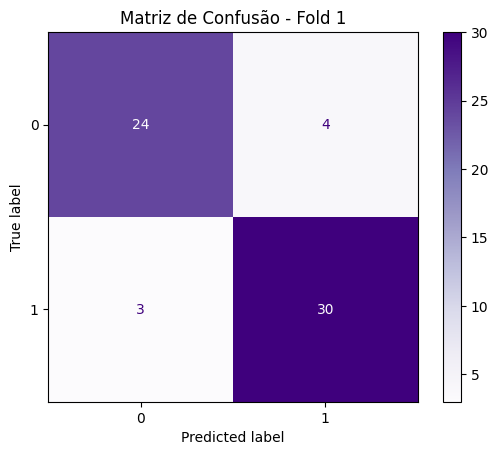

Fold 1 Acc: 0.885 | Prec: 0.882 | Rec: 0.909 | F1: 0.896
Removendo 'thal_2' (p=1.000) no Fold 2
Removendo 'thal_1' (p=0.840) no Fold 2
Removendo 'fbs' (p=0.771) no Fold 2
Removendo 'restecg_2' (p=0.743) no Fold 2
Removendo 'chol' (p=0.553) no Fold 2
Removendo 'slope_1' (p=0.373) no Fold 2
Removendo 'age' (p=0.309) no Fold 2
Removendo 'restecg_1' (p=0.122) no Fold 2
Removendo 'oldpeak' (p=0.101) no Fold 2


/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


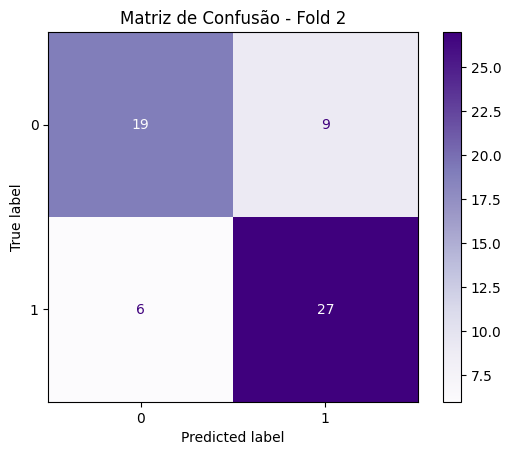

Fold 2 Acc: 0.754 | Prec: 0.750 | Rec: 0.818 | F1: 0.783
Removendo 'slope_1' (p=0.846) no Fold 3
Removendo 'restecg_2' (p=0.742) no Fold 3
Removendo 'thal_3' (p=0.566) no Fold 3
Removendo 'chol' (p=0.592) no Fold 3
Removendo 'age' (p=0.321) no Fold 3
Removendo 'fbs' (p=0.190) no Fold 3
Removendo 'trestbps' (p=0.169) no Fold 3


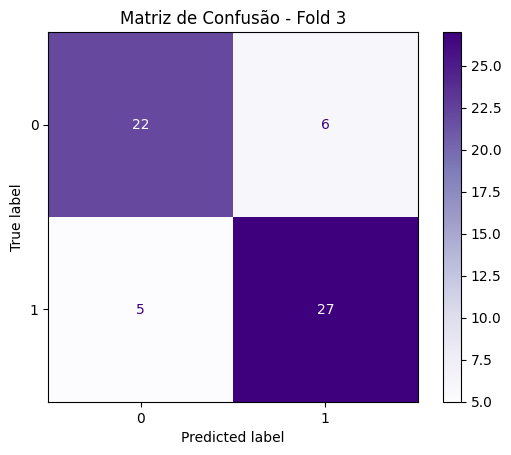

Fold 3 Acc: 0.817 | Prec: 0.818 | Rec: 0.844 | F1: 0.831
Removendo 'thal_3' (p=1.000) no Fold 4
Removendo 'restecg_2' (p=1.000) no Fold 4
Removendo 'slope_2' (p=0.871) no Fold 4
Removendo 'fbs' (p=0.740) no Fold 4
Removendo 'chol' (p=0.485) no Fold 4
Removendo 'age' (p=0.385) no Fold 4
Removendo 'restecg_1' (p=0.283) no Fold 4
Removendo 'trestbps' (p=0.131) no Fold 4
Removendo 'cp_1' (p=0.096) no Fold 4


/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


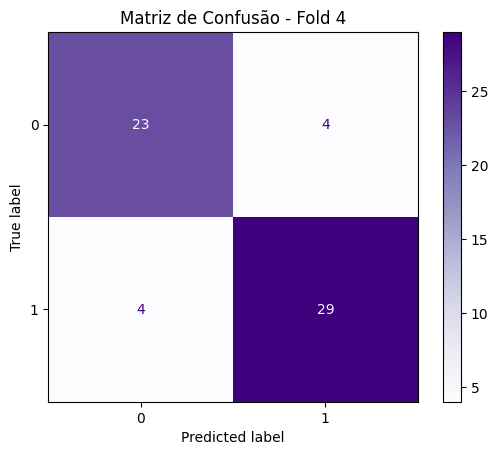

Fold 4 Acc: 0.867 | Prec: 0.879 | Rec: 0.879 | F1: 0.879
Removendo 'slope_2' (p=0.975) no Fold 5
Removendo 'age' (p=0.897) no Fold 5
Removendo 'fbs' (p=0.882) no Fold 5
Removendo 'restecg_2' (p=0.730) no Fold 5
Removendo 'thal_3' (p=0.688) no Fold 5
Removendo 'chol' (p=0.531) no Fold 5
Removendo 'thal_1' (p=0.410) no Fold 5
Removendo 'restecg_1' (p=0.316) no Fold 5
Removendo 'trestbps' (p=0.207) no Fold 5


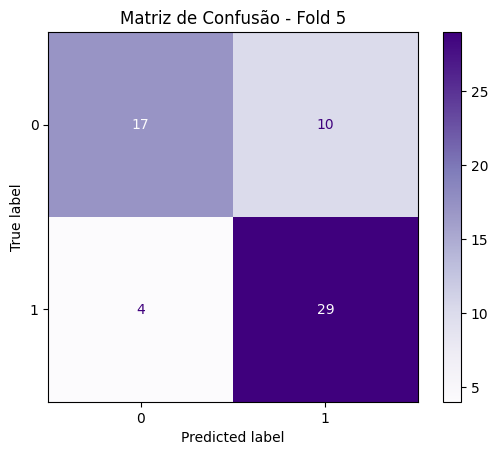

Fold 5 Acc: 0.767 | Prec: 0.744 | Rec: 0.879 | F1: 0.806

Resumo da validação cruzada (5-fold) Logistica (com backward in-fold):
Acurácia média: 0.818 ± 0.052
Precisão média: 0.815 ± 0.060
Recall médio:   0.866 ± 0.032
F1 médio:       0.839 ± 0.043


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import statsmodels.api as sm

# Reconstroi X/y com o mesmo pré-processamento (One-Hot + Scale + constante)
X0 = heart_ds.drop(["target", "thalach", "exang"], axis=1)
y0 = heart_ds["target"].astype(int)

categorical_cols = ['cp', 'thal', 'slope', 'restecg']
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

X_encoded = pd.get_dummies(X0, columns=[c for c in categorical_cols if c in X0.columns], drop_first=True, dtype=int)
cols_to_scale = [c for c in continuous_cols if c in X_encoded.columns]
scaler = StandardScaler()
X_scaled = X_encoded.copy()
if len(cols_to_scale) > 0:
    X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

X_const_all = sm.add_constant(X_scaled)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=829)

accuracies, precisions, recalls, f1s = [], [], [], []
fold = 1

for train_idx, test_idx in skf.split(X_const_all, y0):
    X_tr = X_const_all.iloc[train_idx].reset_index(drop=True)
    X_te = X_const_all.iloc[test_idx].reset_index(drop=True)
    y_tr = y0.iloc[train_idx].reset_index(drop=True)
    y_te = y0.iloc[test_idx].reset_index(drop=True)

    # Backward selection dentro do fold
    threshold = 0.05
    X_tr_sel = X_tr.copy()
    X_te_sel = X_te.copy()

    while True:
        try:
            model_cv = sm.Logit(y_tr, X_tr_sel).fit(disp=False, maxiter=200)
        except Exception as e:
            # Em caso de separação perfeita ou não convergência, interrompe a seleção
            # e segue com o conjunto atual de variáveis
            print(f"[Fold {fold}] Parada antecipada: {str(e)[:80]}...")
            break
        pvals = model_cv.pvalues.drop("const", errors="ignore")
        if pvals.empty:
            break
        worst_var = pvals.idxmax()
        worst_pval = pvals.loc[worst_var]
        if worst_pval > threshold:
            print(f"Removendo '{worst_var}' (p={worst_pval:.3f}) no Fold {fold}")
            X_tr_sel = X_tr_sel.drop(columns=[worst_var])
            X_te_sel = X_te_sel.drop(columns=[worst_var])
        else:
            break

    model_fold = sm.Logit(y_tr, X_tr_sel).fit(disp=False, maxiter=200)
    proba = model_fold.predict(X_te_sel)
    y_pred = (proba > 0.5).astype(int)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(cmap=plt.cm.Purples)
    plt.title(f"Matriz de Confusão - Fold {fold}")
    plt.show()

    print(f"Fold {fold} Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | F1: {f1:.3f}")
    fold += 1

print("\nResumo da validação cruzada (5-fold) Logistica (com backward in-fold):")
print(f"Acurácia média: {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Precisão média: {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
print(f"Recall médio:   {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
print(f"F1 médio:       {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")


Ridge - Métricas no treino/teste
Treino: Acc=0.886 | Prec=0.870 | Rec=0.930 | F1=0.899
Teste : Acc=0.824 | Prec=0.851 | Rec=0.816 | F1=0.833


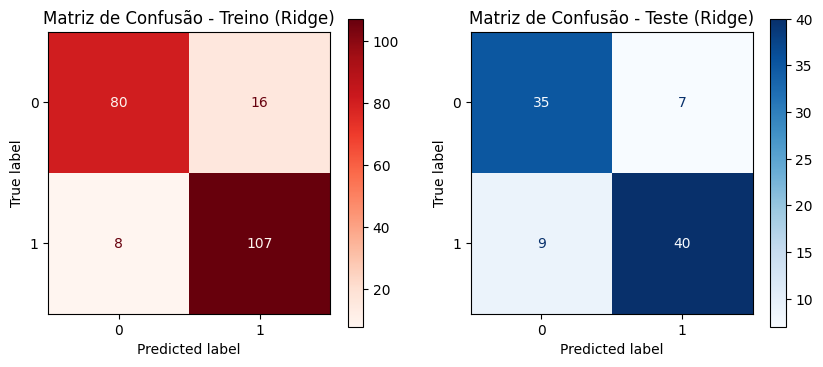

Fold 1 — Acc: 0.852 | Prec: 0.833 | Rec: 0.909 | F1: 0.870
Fold 2 — Acc: 0.885 | Prec: 0.906 | Rec: 0.879 | F1: 0.892
Fold 3 — Acc: 0.817 | Prec: 0.800 | Rec: 0.875 | F1: 0.836
Fold 4 — Acc: 0.883 | Prec: 0.882 | Rec: 0.909 | F1: 0.896
Fold 5 — Acc: 0.817 | Prec: 0.806 | Rec: 0.879 | F1: 0.841

Ridge - CV (5-fold)
Acurácia média: 0.851 ± 0.030
Precisão média: 0.845 ± 0.042
Recall médio:   0.890 ± 0.016
F1 médio:       0.867 ± 0.025


In [36]:
# =================================================
#         LOGIT COM RIDGE (L2) VIA SKLEARN
# =================================================

# Regressão Logística com Ridge (L2) - pipeline consistente (One‑Hot + Scale)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# Pré-processamento igual ao usado na seção de Logística (statsmodels)
X = heart_ds.drop("target", axis=1)
y = heart_ds["target"].astype(int)

categorical_cols = ['cp', 'thal', 'slope', 'restecg']
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

X_enc = pd.get_dummies(X, columns=[c for c in categorical_cols if c in X.columns], drop_first=True, dtype=int)
cols_to_scale = [c for c in continuous_cols if c in X_enc.columns]
scaler = StandardScaler()
X_scaled = X_enc.copy()
if len(cols_to_scale) > 0:
    X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

ridge = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=2000)
ridge.fit(X_train, y_train)

y_pred_tr = ridge.predict(X_train)
y_pred_te = ridge.predict(X_test)

print("Ridge - Métricas no treino/teste")
print(f"Treino: Acc={accuracy_score(y_train, y_pred_tr):.3f} | Prec={precision_score(y_train, y_pred_tr):.3f} | Rec={recall_score(y_train, y_pred_tr):.3f} | F1={f1_score(y_train, y_pred_tr):.3f}")
print(f"Teste : Acc={accuracy_score(y_test, y_pred_te):.3f} | Prec={precision_score(y_test, y_pred_te):.3f} | Rec={recall_score(y_test, y_pred_te):.3f} | F1={f1_score(y_test, y_pred_te):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_tr), display_labels=[0,1]).plot(cmap=plt.cm.Reds, ax=axes[0])
axes[0].set_title("Matriz de Confusão - Treino (Ridge)")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_te), display_labels=[0,1]).plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Matriz de Confusão - Teste (Ridge)")
plt.show()

# Validação cruzada com métricas completas
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=540)
accs, precs, recs, f1s = [], [], [], []
fold = 1
for tr_idx, te_idx in skf.split(X_scaled, y):
    X_tr, X_te = X_scaled.iloc[tr_idx], X_scaled.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
    m = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=2000)
    m.fit(X_tr, y_tr)
    y_hat = m.predict(X_te)
    a = accuracy_score(y_te, y_hat); p = precision_score(y_te, y_hat); r = recall_score(y_te, y_hat); f = f1_score(y_te, y_hat)
    accs.append(a); precs.append(p); recs.append(r); f1s.append(f)
    print(f"Fold {fold} — Acc: {a:.3f} | Prec: {p:.3f} | Rec: {r:.3f} | F1: {f:.3f}")
    fold += 1

print("\nRidge - CV (5-fold)")
print(f"Acurácia média: {np.mean(accs):.3f} ± {np.std(accs):.3f}")
print(f"Precisão média: {np.mean(precs):.3f} ± {np.std(precs):.3f}")
print(f"Recall médio:   {np.mean(recs):.3f} ± {np.std(recs):.3f}")
print(f"F1 médio:       {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")

In [38]:
# =================
# COEFICIENTES RIDGE
# =================
print("\nCoeficientes do modelo Ridge:")
m.coef_


Coeficientes do modelo Ridge:


array([[ 0.01019537, -0.90317327, -0.31633782, -0.09842536,  0.46347624,
         0.58196783, -0.87046814, -0.40855969, -0.82580752,  0.75035098,
         1.44948886,  1.21108341,  0.3702081 ,  0.76608275, -0.82871424,
        -0.4416088 ,  0.27708713, -0.01385616, -0.14238547]])

Lasso - Métricas no treino/teste
Treino: Acc=0.877 | Prec=0.862 | Rec=0.922 | F1=0.891
Teste : Acc=0.813 | Prec=0.833 | Rec=0.816 | F1=0.825


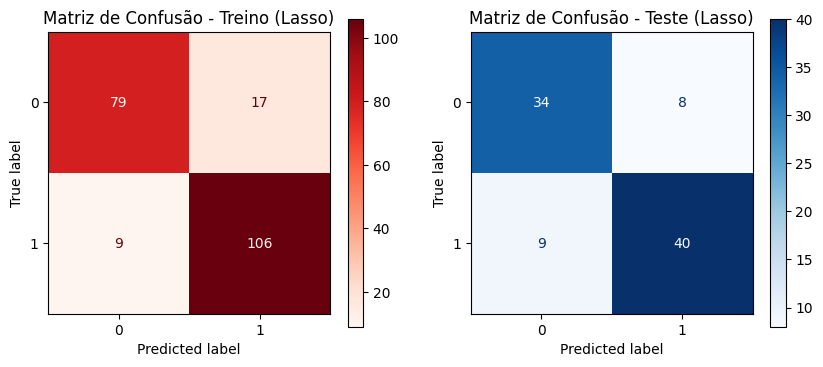


Coeficientes Lasso (não-zero em ordem de magnitude):
      feature      coef
10       cp_2  2.185174
11       cp_3  1.485780
9        cp_1  1.080776
1         sex -0.974458
8          ca -0.765559
13     thal_2  0.713609
14     thal_3 -0.697038
5     thalach  0.638298
6       exang -0.602252
17  restecg_1  0.532676
16    slope_2  0.406815
7     oldpeak -0.278756
2    trestbps -0.200207
3        chol -0.148197
15    slope_1 -0.079221
Fold 1 — Acc: 0.820 | Prec: 0.775 | Rec: 0.939 | F1: 0.849
Fold 2 — Acc: 0.885 | Prec: 0.906 | Rec: 0.879 | F1: 0.892
Fold 3 — Acc: 0.800 | Prec: 0.794 | Rec: 0.844 | F1: 0.818
Fold 4 — Acc: 0.900 | Prec: 0.886 | Rec: 0.939 | F1: 0.912
Fold 5 — Acc: 0.800 | Prec: 0.784 | Rec: 0.879 | F1: 0.829

Lasso - CV (5-fold)
Acurácia média: 0.841 ± 0.043
Precisão média: 0.829 ± 0.055
Recall médio:   0.896 ± 0.038
F1 médio:       0.860 ± 0.036


In [40]:
# ================================================
#        LOGIT COM LASSO (L1) VIA SKLEARN
# ================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# Pré-processamento igual ao Ridge (One‑Hot + Scale)
X = heart_ds.drop("target", axis=1)
y = heart_ds["target"].astype(int)

categorical_cols = ['cp', 'thal', 'slope', 'restecg']
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

X_enc = pd.get_dummies(X, columns=[c for c in categorical_cols if c in X.columns], drop_first=True, dtype=int)
cols_to_scale = [c for c in continuous_cols if c in X_enc.columns]
scaler = StandardScaler()
X_scaled = X_enc.copy()
if len(cols_to_scale) > 0:
    X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

lasso = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=2000)
lasso.fit(X_train, y_train)

y_pred_tr = lasso.predict(X_train)
y_pred_te = lasso.predict(X_test)

print("Lasso - Métricas no treino/teste")
print(f"Treino: Acc={accuracy_score(y_train, y_pred_tr):.3f} | Prec={precision_score(y_train, y_pred_tr):.3f} | Rec={recall_score(y_train, y_pred_tr):.3f} | F1={f1_score(y_train, y_pred_tr):.3f}")
print(f"Teste : Acc={accuracy_score(y_test, y_pred_te):.3f} | Prec={precision_score(y_test, y_pred_te):.3f} | Rec={recall_score(y_test, y_pred_te):.3f} | F1={f1_score(y_test, y_pred_te):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_tr), display_labels=[0,1]).plot(cmap=plt.cm.Reds, ax=axes[0])
axes[0].set_title("Matriz de Confusão - Treino (Lasso)")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_te), display_labels=[0,1]).plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Matriz de Confusão - Teste (Lasso)")
plt.show()

# Inspecionar coeficientes (variáveis selecionadas pelo Lasso)
coefs = pd.DataFrame({
    'feature': X_train.columns,
    'coef': lasso.coef_[0]
}).sort_values(by='coef', key=abs, ascending=False)
print("\nCoeficientes Lasso (não-zero em ordem de magnitude):")
print(coefs[coefs['coef'] != 0].head(15))

# Validação cruzada com métricas completas
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=540)
accs, precs, recs, f1s = [], [], [], []
fold = 1
for tr_idx, te_idx in skf.split(X_scaled, y):
    X_tr, X_te = X_scaled.iloc[tr_idx], X_scaled.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
    m = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=2000)
    m.fit(X_tr, y_tr)
    y_hat = m.predict(X_te)
    a = accuracy_score(y_te, y_hat); p = precision_score(y_te, y_hat); r = recall_score(y_te, y_hat); f = f1_score(y_te, y_hat)
    accs.append(a); precs.append(p); recs.append(r); f1s.append(f)
    print(f"Fold {fold} — Acc: {a:.3f} | Prec: {p:.3f} | Rec: {r:.3f} | F1: {f:.3f}")
    fold += 1

print("\nLasso - CV (5-fold)")
print(f"Acurácia média: {np.mean(accs):.3f} ± {np.std(accs):.3f}")
print(f"Precisão média: {np.mean(precs):.3f} ± {np.std(precs):.3f}")
print(f"Recall médio:   {np.mean(recs):.3f} ± {np.std(recs):.3f}")
print(f"F1 médio:       {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")

In [41]:
# ======================
# COEFICIENTES LASSO
# ======================

print("\nCoeficientes do modelo Lasso:")
m.coef_


Coeficientes do modelo Lasso:


array([[ 0.        , -0.6437725 , -0.27487115, -0.05386618,  0.28803237,
         0.54619534, -0.76246469, -0.39163648, -0.79170497,  0.86209069,
         1.6349353 ,  1.36071105,  0.39077017,  1.10424802, -0.5417625 ,
        -0.03530783,  0.53667585,  0.        ,  0.        ]])

Uma coisa interessante e que converge com a visão intuitiva é a tendencia do lasso de a zerar coeficientes, enquanto o ridge, apesar de deixa-los pequenos, nao costuma zerar nenhum. 

### KNN

KNN - Cross-Validation com Seleção de Hiperparâmetros
Fold 1 - k=7, metric=cosine
  CV interno: 0.857 | Acc: 0.767 | Prec: 0.810 | Rec: 0.739 | F1: 0.773
Fold 1 - k=7, metric=cosine
  CV interno: 0.857 | Acc: 0.767 | Prec: 0.810 | Rec: 0.739 | F1: 0.773
Fold 2 - k=15, metric=cosine
  CV interno: 0.829 | Acc: 0.857 | Prec: 0.840 | Rec: 0.913 | F1: 0.875
Fold 2 - k=15, metric=cosine
  CV interno: 0.829 | Acc: 0.857 | Prec: 0.840 | Rec: 0.913 | F1: 0.875
Fold 3 - k=7, metric=cosine
  CV interno: 0.822 | Acc: 0.857 | Prec: 0.947 | Rec: 0.783 | F1: 0.857
Fold 3 - k=7, metric=cosine
  CV interno: 0.822 | Acc: 0.857 | Prec: 0.947 | Rec: 0.783 | F1: 0.857
Fold 4 - k=11, metric=cosine
  CV interno: 0.864 | Acc: 0.786 | Prec: 0.769 | Rec: 0.870 | F1: 0.816
Fold 4 - k=11, metric=cosine
  CV interno: 0.864 | Acc: 0.786 | Prec: 0.769 | Rec: 0.870 | F1: 0.816
Fold 5 - k=11, metric=cosine
  CV interno: 0.840 | Acc: 0.857 | Prec: 0.840 | Rec: 0.913 | F1: 0.875

KNN - Resultados Cross-Validation (5-fol

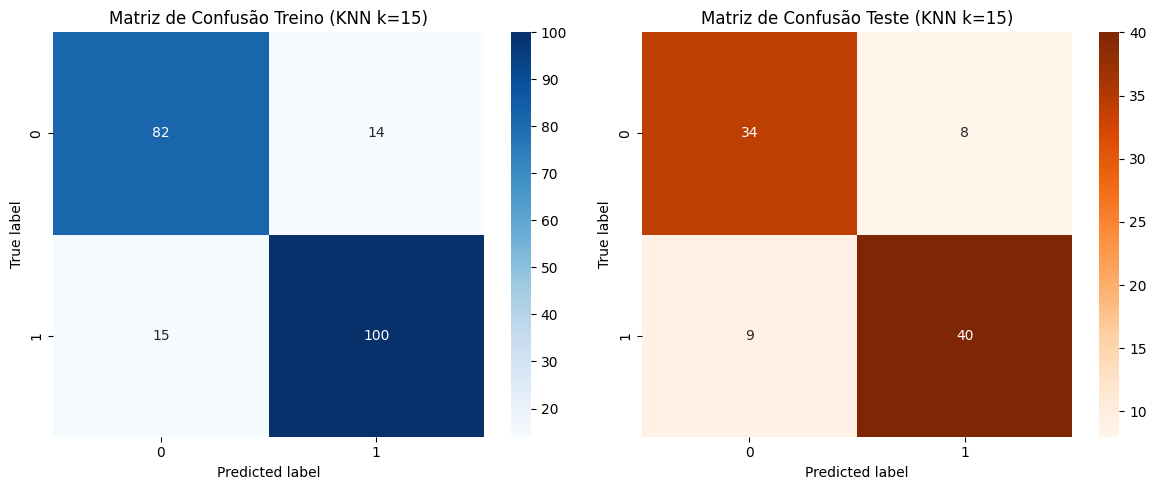

In [22]:
# KNN com Cross-Validation e Seleção de Hiperparâmetros
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['cp','thal','slope','restecg']
X_knn = pd.get_dummies(heart_ds.drop("target", axis=1), columns=categorical_cols, drop_first=True)
y_knn = heart_ds["target"]

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X_knn, y_knn, test_size=0.3, random_state=42, stratify=y_knn)

# Hiperparâmetros para teste
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
metrics = ['euclidean', 'manhattan', 'chebyshev', 'minkowski', 'cosine']

# Cross-validation externa (5-fold)
skf_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

print("KNN - Cross-Validation com Seleção de Hiperparâmetros")
print("="*60)

for fold, (train_idx, val_idx) in enumerate(skf_outer.split(X_train, y_train), 1):
    X_tr_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Normalização por fold
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr_fold)
    X_val_scaled = scaler.transform(X_val_fold)
    
    # Cross-validation interna para seleção de hiperparâmetros
    skf_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    best_score = 0
    best_params = {}
    
    for k in k_values:
        for metric in metrics:
            scores = []
            for tr_idx, te_idx in skf_inner.split(X_tr_scaled, y_tr_fold):
                X_tr_inner, X_te_inner = X_tr_scaled[tr_idx], X_tr_scaled[te_idx]
                y_tr_inner, y_te_inner = y_tr_fold.iloc[tr_idx], y_tr_fold.iloc[te_idx]
                
                try:
                    knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
                    knn.fit(X_tr_inner, y_tr_inner)
                    y_pred = knn.predict(X_te_inner)
                    scores.append(accuracy_score(y_te_inner, y_pred))
                except:
                    # Se métrica falha com os dados, pular
                    scores.append(0)
            
            mean_score = np.mean(scores)
            if mean_score > best_score:
                best_score = mean_score
                best_params = {'k': k, 'metric': metric}
    
    # Treinar melhor modelo no fold completo
    best_knn = KNeighborsClassifier(n_neighbors=best_params['k'], metric=best_params['metric'])
    best_knn.fit(X_tr_scaled, y_tr_fold)
    
    # Avaliar no fold de validação
    y_pred_fold = best_knn.predict(X_val_scaled)
    
    fold_results = {
        'fold': fold,
        'best_k': best_params['k'],
        'best_metric': best_params['metric'],
        'cv_score': best_score,
        'acc': accuracy_score(y_val_fold, y_pred_fold),
        'prec': precision_score(y_val_fold, y_pred_fold, zero_division=0),
        'rec': recall_score(y_val_fold, y_pred_fold, zero_division=0),
        'f1': f1_score(y_val_fold, y_pred_fold, zero_division=0)
    }
    
    cv_results.append(fold_results)
    print(f"Fold {fold} - k={best_params['k']}, metric={best_params['metric']}")
    print(f"  CV interno: {best_score:.3f} | Acc: {fold_results['acc']:.3f} | Prec: {fold_results['prec']:.3f} | Rec: {fold_results['rec']:.3f} | F1: {fold_results['f1']:.3f}")

# Calcular médias
cv_df = pd.DataFrame(cv_results)
mean_results = {
    'acc_mean': cv_df['acc'].mean(),
    'acc_std': cv_df['acc'].std(),
    'prec_mean': cv_df['prec'].mean(),
    'prec_std': cv_df['prec'].std(),
    'rec_mean': cv_df['rec'].mean(),
    'rec_std': cv_df['rec'].std(),
    'f1_mean': cv_df['f1'].mean(),
    'f1_std': cv_df['f1'].std()
}

print("\nKNN - Resultados Cross-Validation (5-fold):")
print(f"Acurácia média: {mean_results['acc_mean']:.3f} ± {mean_results['acc_std']:.3f}")
print(f"Precisão média: {mean_results['prec_mean']:.3f} ± {mean_results['prec_std']:.3f}")
print(f"Recall médio:   {mean_results['rec_mean']:.3f} ± {mean_results['rec_std']:.3f}")
print(f"F1 médio:       {mean_results['f1_mean']:.3f} ± {mean_results['f1_std']:.3f}")

# Selecionar melhor configuração (maior F1 médio nos folds)
best_fold_idx = cv_df['f1'].idxmax()
final_best_k = cv_df.loc[best_fold_idx, 'best_k']
final_best_metric = cv_df.loc[best_fold_idx, 'best_metric']

print(f"\nMelhor configuração: k={final_best_k}, métrica={final_best_metric}")

# Treinar modelo final no conjunto de treino completo
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled = scaler_final.transform(X_test)

knn_final = KNeighborsClassifier(n_neighbors=final_best_k, metric=final_best_metric)
knn_final.fit(X_train_scaled, y_train)

# Avaliação final
y_pred_train_final = knn_final.predict(X_train_scaled)
y_pred_test_final = knn_final.predict(X_test_scaled)

print(f"\nKNN — Avaliação Final (k={final_best_k}, {final_best_metric}):")
print(f"Treino: Acc={accuracy_score(y_train, y_pred_train_final):.3f} | Prec={precision_score(y_train, y_pred_train_final):.3f} | Rec={recall_score(y_train, y_pred_train_final):.3f} | F1={f1_score(y_train, y_pred_train_final):.3f}")
print(f"Teste : Acc={accuracy_score(y_test, y_pred_test_final):.3f} | Prec={precision_score(y_test, y_pred_test_final):.3f} | Rec={recall_score(y_test, y_pred_test_final):.3f} | F1={f1_score(y_test, y_pred_test_final):.3f}")

# Matrizes de confusão
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Treino
cm_train = confusion_matrix(y_train, y_pred_train_final)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Matriz de Confusão Treino (KNN k={final_best_k})')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

# Teste
cm_test = confusion_matrix(y_test, y_pred_test_final)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title(f'Matriz de Confusão Teste (KNN k={final_best_k})')
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')

plt.tight_layout()
plt.show()

# Salvar resultados para comparação
knn_cv_results = mean_results.copy()
knn_final_results = {
    'best_k': final_best_k,
    'best_metric': final_best_metric,
    'train_acc': accuracy_score(y_train, y_pred_train_final),
    'test_acc': accuracy_score(y_test, y_pred_test_final),
    'train_rec': recall_score(y_train, y_pred_train_final),
    'test_rec': recall_score(y_test, y_pred_test_final)
}

### SVM

SVM (RBF) - Treinamento e Avaliação

Desempenho no conjunto de TREINO:
Acurácia : 0.924
Precisão : 0.909
Recall   : 0.957
F1-Score : 0.932

Desempenho no conjunto de TESTE:
Acurácia : 0.824
Precisão : 0.851
Recall   : 0.816
F1-Score : 0.833


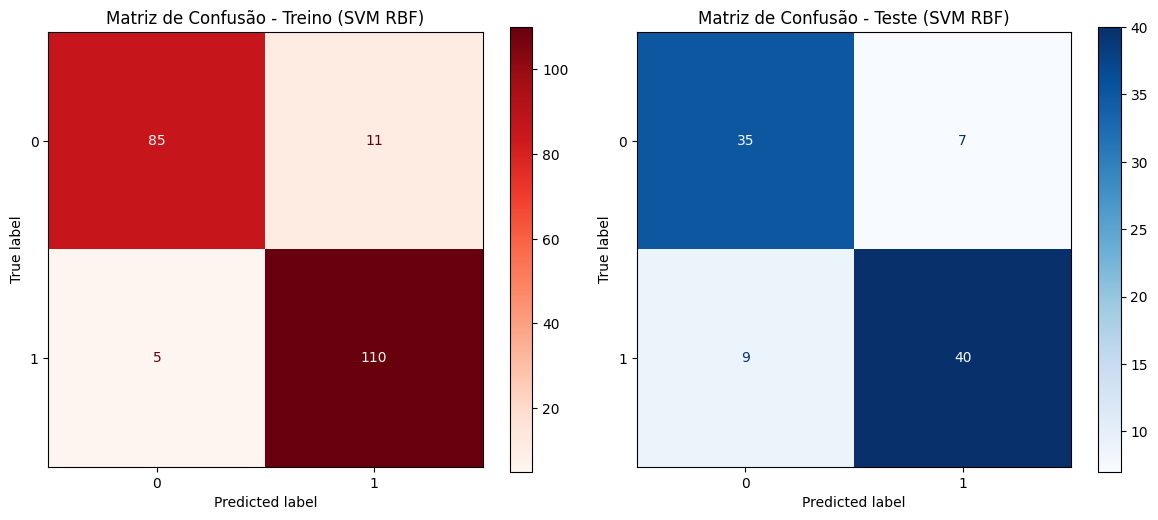


VALIDAÇÃO CRUZADA 5-FOLD (Stratified)
Fold 1 - Acc: 0.803 | Prec: 0.889 | Rec: 0.727 | F1: 0.800


<Figure size 600x500 with 0 Axes>

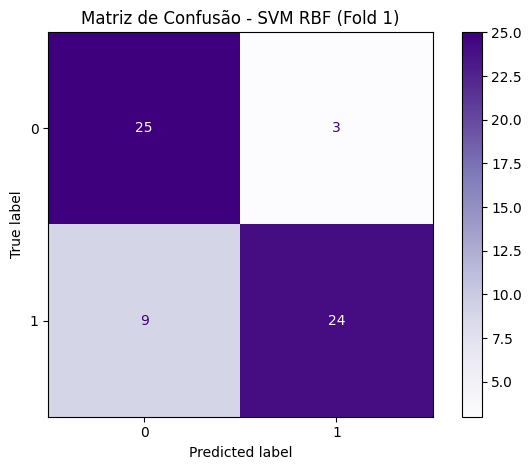

Fold 2 - Acc: 0.803 | Prec: 0.756 | Rec: 0.939 | F1: 0.838


<Figure size 600x500 with 0 Axes>

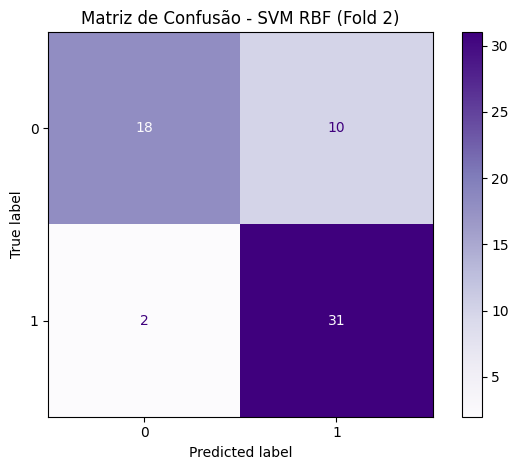

Fold 3 - Acc: 0.767 | Prec: 0.765 | Rec: 0.812 | F1: 0.788


<Figure size 600x500 with 0 Axes>

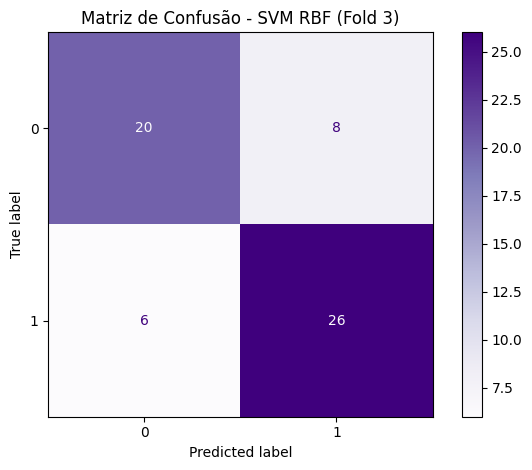

Fold 4 - Acc: 0.867 | Prec: 0.879 | Rec: 0.879 | F1: 0.879


<Figure size 600x500 with 0 Axes>

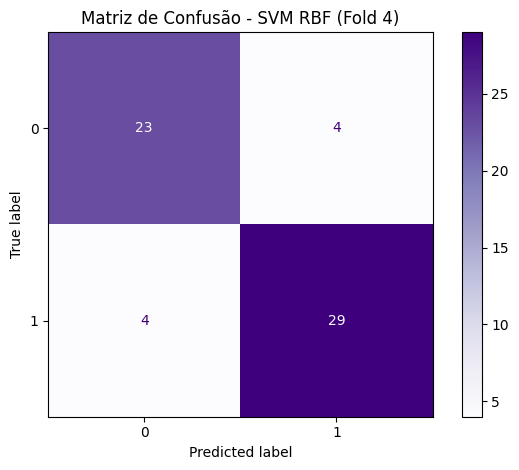

Fold 5 - Acc: 0.800 | Prec: 0.800 | Rec: 0.848 | F1: 0.824


<Figure size 600x500 with 0 Axes>

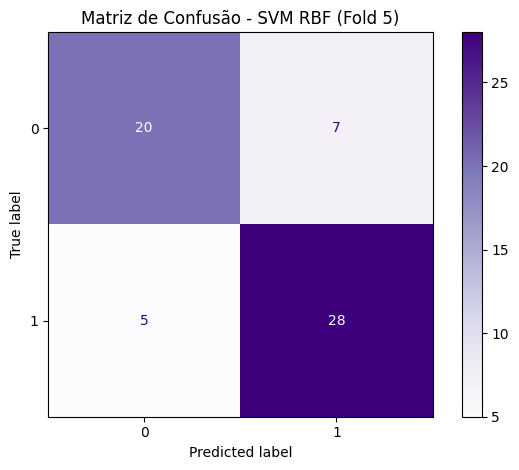


RESUMO DA VALIDAÇÃO CRUZADA (SVM RBF)
Acurácia média : 0.808 ± 0.036
Precisão média : 0.818 ± 0.063
Recall médio   : 0.841 ± 0.079
F1 médio       : 0.826 ± 0.036


In [23]:
# SVM com Pipeline completo (One-Hot + Scale) e Cross-Validation
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Preparação dos dados
X = heart_ds.drop("target", axis=1)
y = heart_ds["target"].astype(int)

# Identificar colunas categóricas e numéricas
categorical_cols = ['cp', 'thal', 'slope', 'restecg']
categorical_cols = [c for c in categorical_cols if c in X.columns]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

# 2. Criar o preprocessador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

# 3. Criar o pipeline SVM
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

# 4. Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 5. Treinar e avaliar no conjunto de teste
print("SVM (RBF) - Treinamento e Avaliação")
print("=" * 60)

svm_pipeline.fit(X_train, y_train)

# Predições
y_pred_train = svm_pipeline.predict(X_train)
y_pred_test = svm_pipeline.predict(X_test)

# Métricas no treino e teste
print("\nDesempenho no conjunto de TREINO:")
print(f"Acurácia : {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Precisão : {precision_score(y_train, y_pred_train, zero_division=0):.3f}")
print(f"Recall   : {recall_score(y_train, y_pred_train, zero_division=0):.3f}")
print(f"F1-Score : {f1_score(y_train, y_pred_train, zero_division=0):.3f}")

print("\nDesempenho no conjunto de TESTE:")
print(f"Acurácia : {accuracy_score(y_test, y_pred_test):.3f}")
print(f"Precisão : {precision_score(y_test, y_pred_test, zero_division=0):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_test, zero_division=0):.3f}")
print(f"F1-Score : {f1_score(y_test, y_pred_test, zero_division=0):.3f}")

# Matrizes de Confusão (Treino e Teste)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Treino
cm_train = confusion_matrix(y_train, y_pred_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=[0, 1])
disp_train.plot(cmap='Reds', ax=axes[0], values_format='d')
axes[0].set_title('Matriz de Confusão - Treino (SVM RBF)')

# Teste
cm_test = confusion_matrix(y_test, y_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=[0, 1])
disp_test.plot(cmap='Blues', ax=axes[1], values_format='d')
axes[1].set_title('Matriz de Confusão - Teste (SVM RBF)')

plt.tight_layout()
plt.show()

# 6. Cross-Validation (5-fold estratificada)
print("\n" + "=" * 60)
print("VALIDAÇÃO CRUZADA 5-FOLD (Stratified)")
print("=" * 60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]
    
    # Treinar pipeline no fold
    svm_cv = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
    ])
    
    svm_cv.fit(X_train_fold, y_train_fold)
    y_pred_fold = svm_cv.predict(X_val_fold)
    
    # Calcular métricas
    acc = accuracy_score(y_val_fold, y_pred_fold)
    prec = precision_score(y_val_fold, y_pred_fold, zero_division=0)
    rec = recall_score(y_val_fold, y_pred_fold, zero_division=0)
    f1 = f1_score(y_val_fold, y_pred_fold, zero_division=0)
    
    cv_results.append({
        'fold': fold,
        'acc': acc,
        'prec': prec,
        'rec': rec,
        'f1': f1
    })
    
    print(f"Fold {fold} - Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | F1: {f1:.3f}")
    
    # Matriz de confusão do fold
    cm_fold = confusion_matrix(y_val_fold, y_pred_fold)
    disp_fold = ConfusionMatrixDisplay(confusion_matrix=cm_fold, display_labels=[0, 1])
    
    plt.figure(figsize=(6, 5))
    disp_fold.plot(cmap='Purples', values_format='d')
    plt.title(f'Matriz de Confusão - SVM RBF (Fold {fold})')
    plt.tight_layout()
    plt.show()

# Resumo da validação cruzada
cv_df = pd.DataFrame(cv_results)
print("\n" + "=" * 60)
print("RESUMO DA VALIDAÇÃO CRUZADA (SVM RBF)")
print("=" * 60)
print(f"Acurácia média : {cv_df['acc'].mean():.3f} ± {cv_df['acc'].std():.3f}")
print(f"Precisão média : {cv_df['prec'].mean():.3f} ± {cv_df['prec'].std():.3f}")
print(f"Recall médio   : {cv_df['rec'].mean():.3f} ± {cv_df['rec'].std():.3f}")
print(f"F1 médio       : {cv_df['f1'].mean():.3f} ± {cv_df['f1'].std():.3f}")

# Salvar resultados
svm_cv_results = {
    'acc_mean': cv_df['acc'].mean(),
    'acc_std': cv_df['acc'].std(),
    'prec_mean': cv_df['prec'].mean(),
    'prec_std': cv_df['prec'].std(),
    'rec_mean': cv_df['rec'].mean(),
    'rec_std': cv_df['rec'].std(),
    'f1_mean': cv_df['f1'].mean(),
    'f1_std': cv_df['f1'].std()
}

svm_final_results = {
    'train_acc': accuracy_score(y_train, y_pred_train),
    'test_acc': accuracy_score(y_test, y_pred_test),
    'train_rec': recall_score(y_train, y_pred_train),
    'test_rec': recall_score(y_test, y_pred_test),
    'test_f1': f1_score(y_test, y_pred_test)
}


### Rede Neural:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import random

seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

X = heart_ds.drop("target", axis=1).to_numpy()
y = heart_ds["target"].to_numpy()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)


class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()
        self.model = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(input_dim, 32),   
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),        
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(16, 1),  
            nn.Sigmoid()                
        )
        
    def forward(self, x):
        return self.model(x)

input_dim = X_train.shape[1]
model = SimpleNN(input_dim)

criterion = nn.BCELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

best_acc = 0
patience = 25
counter = 0

epochs = 20000
for epoch in range(epochs):
    model.train()
    
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

    model.eval()
    with torch.no_grad():
        y_pred_val = (model(X_test_tensor) > 0.5).float()
        acc_val = accuracy_score(y_test_tensor, y_pred_val)
    
    if acc_val > best_acc:
        best_acc = acc_val
        counter = 0


model.eval()
with torch.no_grad():
    y_pred_test_probs = model(X_test_tensor)
    y_pred_test = (y_pred_test_probs > 0.5).float() 


    y_pred_train_probs = model(X_train_tensor)
    y_pred_train = (y_pred_train_probs > 0.5).float()

# Acurácia
acc_test = accuracy_score(y_test_tensor, y_pred_test)
acc_train = accuracy_score(y_train_tensor, y_pred_train)

print(f"Acurácia no conjunto de treino: {acc_train:.3f}")
print(f"Acurácia no conjunto de teste : {acc_test:.3f}")



Epoch [20/1000], Loss: 0.6775
Epoch [40/1000], Loss: 0.6197
Epoch [60/1000], Loss: 0.5513
Early stopping na epoch 62
Acurácia no conjunto de treino: 0.844
Acurácia no conjunto de teste : 0.824
Epoch [60/1000], Loss: 0.5513
Early stopping na epoch 62
Acurácia no conjunto de treino: 0.844
Acurácia no conjunto de teste : 0.824


In [24]:
# Cross-validation summary across models (5-fold Stratified)
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Use existing dataframe if available in kernel, otherwise load
try:
    data = heart_ds.copy()
    print("Using 'heart_ds' from kernel")
except Exception:
    try:
        data = df.copy()
        print("Using 'df' from kernel")
    except Exception:
        data = pd.read_csv('heart.csv')
        print("Loaded 'heart.csv' from disk")

# identify target column
target_col = None
for cand in ['target', 'Target', 'condition', 'Condition', 'y']:
    if cand in data.columns:
        target_col = cand
        break
if target_col is None:
    # fallback: assume last column is target
    target_col = data.columns[-1]
    print(f"Target column inferred as '{target_col}'")

y = data[target_col]
X = data.drop(columns=[target_col]).copy()

# categorical columns used earlier
categorical_cols = [c for c in ['cp','thal','slope','restecg'] if c in X.columns]
X_enc = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# continuous numeric columns
numeric_cols = X_enc.select_dtypes(include=[np.number]).columns.tolist()

# Prepare models
models = {
    'Logistic (approx unreg)': LogisticRegression(C=1e6, solver='lbfgs', max_iter=10000),
    'Ridge (L2)': LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=10000),
    'Lasso (L1)': LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=10000),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)': SVC(kernel='rbf', probability=False)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    accs, precs, recs, f1s = [], [], [], []
    for train_idx, test_idx in skf.split(X_enc, y):
        X_tr, X_te = X_enc.iloc[train_idx].copy(), X_enc.iloc[test_idx].copy()
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        # scale numeric cols per fold
        scaler = StandardScaler()
        X_tr[numeric_cols] = scaler.fit_transform(X_tr[numeric_cols])
        X_te[numeric_cols] = scaler.transform(X_te[numeric_cols])

        # fit
        try:
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_te)
        except Exception as e:
            # if model fails (e.g., QDA singular), record NaNs
            print(f"Model {name} failed on a fold: {e}")
            y_pred = np.zeros_like(y_te)

        accs.append(accuracy_score(y_te, y_pred))
        precs.append(precision_score(y_te, y_pred, zero_division=0))
        recs.append(recall_score(y_te, y_pred, zero_division=0))
        f1s.append(f1_score(y_te, y_pred, zero_division=0))

    results.append({
        'model': name,
        'acc_mean': np.mean(accs), 'acc_std': np.std(accs),
        'prec_mean': np.mean(precs), 'prec_std': np.std(precs),
        'rec_mean': np.mean(recs), 'rec_std': np.std(recs),
        'f1_mean': np.mean(f1s), 'f1_std': np.std(f1s)
    })

res_df = pd.DataFrame(results).set_index('model')
# format results
res_fmt = res_df.copy()
for col in ['acc_mean','prec_mean','rec_mean','f1_mean']:
    std_col = col.replace('_mean','_std')
    res_fmt[col] = res_df[col].round(3).astype(str) + ' ± ' + res_df[std_col].round(3).astype(str)

display(res_fmt[['acc_mean','prec_mean','rec_mean','f1_mean']])

# Save to notebook variable for later referencing
cv_summary = res_df

# Also print sorted by recall mean (important for minimizing false negatives)
print('\nModels sorted by mean Recall:')
print(res_df.sort_values('rec_mean', ascending=False)[['rec_mean','rec_std']])

Using 'heart_ds' from kernel


/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/richa/projects/ML_Rodrigo/final_project_av2/final_proj/lib/python3.12/site-packages/sklearn/discriminant_a

,acc_mean,prec_mean,rec_mean,f1_mean
model,,,,
Logistic (approx unreg),0.824 ± 0.047,0.831 ± 0.029,0.853 ± 0.118,0.837 ± 0.056
Ridge (L2),0.844 ± 0.036,0.847 ± 0.039,0.878 ± 0.104,0.857 ± 0.043
Lasso (L1),0.841 ± 0.031,0.845 ± 0.06,0.878 ± 0.092,0.855 ± 0.033
LDA,0.831 ± 0.035,0.828 ± 0.031,0.878 ± 0.117,0.846 ± 0.048
QDA,0.637 ± 0.157,0.556 ± 0.305,0.72 ± 0.366,0.615 ± 0.313
KNN (k=5),0.824 ± 0.018,0.842 ± 0.021,0.835 ± 0.063,0.837 ± 0.024
SVM (RBF),0.808 ± 0.032,0.818 ± 0.056,0.841 ± 0.071,0.826 ± 0.032



Models sorted by mean Recall:
                         rec_mean   rec_std
model                                      
Ridge (L2)               0.877841  0.103503
Lasso (L1)               0.877841  0.092245
LDA                      0.877841  0.116839
Logistic (approx unreg)  0.853220  0.117988
SVM (RBF)                0.841288  0.070585
KNN (k=5)                0.835038  0.063475
QDA                      0.720265  0.366029


Uma das coisas interessantes que se pode notar aqui é o fato de que o QDA apresentou uma variancia maior e uma acuracia media menor nos dados de validação em relaçao ao LDA. Isso ilustra o fato de que modelos mais complexos podem apresentar oveffit.